# Regressions

this is some actual data and will use the diffrerent models to make statement on the relation between populism and the videos

## Bert

this analysis starts with the bert model as a baseline

In [1]:
import pandas as pd
df = pd.read_parquet("./data/out/videos.parquet")
print(df.columns.tolist())

['id', 'etag', 'kind', 'channel_id', 'title', 'description', 'published_at', 'category_id', 'default_language', 'default_audio_language', 'duration', 'duration_seconds', 'definition', 'dimension', 'caption', 'licensed_content', 'projection', 'live_broadcast_content', 'view_count', 'like_count', 'comment_count', 'favorite_count', 'upload_status', 'privacy_status', 'license', 'embeddable', 'public_stats_viewable', 'made_for_kids', 'thumbnail_default_url', 'thumbnail_default_width', 'thumbnail_default_height', 'thumbnail_medium_url', 'thumbnail_medium_width', 'thumbnail_medium_height', 'thumbnail_high_url', 'thumbnail_high_width', 'thumbnail_high_height', 'thumbnail_standard_url', 'thumbnail_standard_width', 'thumbnail_standard_height', 'thumbnail_maxres_url', 'thumbnail_maxres_width', 'thumbnail_maxres_height', 'whisper_transcript_raw', 'whisper_transcript_text', 'word_count', 'tags', 'created_at', 'updated_at', 'channel_title', 'bert_output', 'llama-3b-inst-4bit_full_anti_elitism', 'lla

In [2]:
# ============================================================
# SETUP
# ============================================================

# Core
import pandas as pd
import numpy as np

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ggplot2-style theme
plt.style.use('ggplot')

mpl.rcParams.update({
    # Font
    'font.family':        'sans-serif',
    'font.size':          12,
    'axes.titlesize':     14,
    'axes.titleweight':   'bold',
    'axes.labelsize':     12,

    # Grid (ggplot2-like: white panel, grey grid)
    'axes.facecolor':     '#EBEBEB',
    'figure.facecolor':   'white',
    'axes.edgecolor':     'white',
    'grid.color':         'white',
    'grid.linewidth':     1.0,
    'axes.grid':          True,

    # Ticks
    'xtick.color':        '#555555',
    'ytick.color':        '#555555',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,

    # Lines & points
    'lines.linewidth':    1.8,
    'patch.edgecolor':    'none',

    # Figure size
    'figure.figsize':     (8, 5),
    'figure.dpi':         120,
})

# ggplot2-inspired color palette
COLORS = [
    '#F8766D', '#00BFC4', '#7CAE00', '#C77CFF',
    '#FF7F00', '#A3A500', '#00B0F6', '#E76BF3'
]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=COLORS)

print("Setup complete ✓")

Setup complete ✓


In [3]:
# ============================================================
# DATA PREP
# ============================================================
import ast

# --- Parse bert_output string into individual columns ---
def parse_bert(val):
    try:
        parsed = ast.literal_eval(val)
        return pd.Series({
            'bert_anti_elitism':   parsed[0],
            'bert_people_centrism': parsed[1],
            'bert_left_ideology':  parsed[2],
            'bert_right_ideology': parsed[3],
        })
    except:
        return pd.Series({
            'bert_anti_elitism':   np.nan,
            'bert_people_centrism': np.nan,
            'bert_left_ideology':  np.nan,
            'bert_right_ideology': np.nan,
        })

bert_cols = df['bert_output'].apply(parse_bert)
df = pd.concat([df, bert_cols], axis=1)

# --- Numeric conversion & log-transforms for skewed engagement vars ---
engagement_vars = ['view_count', 'like_count', 'comment_count', 'duration_seconds', 'word_count']
df[engagement_vars] = df[engagement_vars].apply(pd.to_numeric, errors='coerce')

for col in engagement_vars:
    df[f'log_{col}'] = np.log1p(df[col])  # log1p handles zeros safely

# --- Define target dimensions ---
BERT_DIMS = {
    'Anti-Elitism':    'bert_anti_elitism',
    'People-Centrism': 'bert_people_centrism',
    'Left Ideology':   'bert_left_ideology',
    'Right Ideology':  'bert_right_ideology',
}

PREDICTORS = {
    'Views (log)':    'log_view_count',
    'Likes (log)':    'log_like_count',
    'Comments (log)': 'log_comment_count',
    'Duration (log)': 'log_duration_seconds',
    'Word Count (log)':'log_word_count',
}

# --- Quick sanity check ---
print(f"Rows: {len(df)}")
print(f"\nBERT dimensions summary:")
print(df[[*BERT_DIMS.values()]].describe().round(3))
print(f"\nEngagement vars summary:")
print(df[[*PREDICTORS.values()]].describe().round(3))

Rows: 410

BERT dimensions summary:
       bert_anti_elitism  bert_people_centrism  bert_left_ideology  \
count            400.000               400.000             400.000   
mean               0.617                 0.195               0.099   
std                0.417                 0.278               0.179   
min                0.003                 0.002               0.003   
25%                0.074                 0.012               0.012   
50%                0.884                 0.039               0.034   
75%                0.982                 0.322               0.093   
max                0.998                 0.994               0.986   

       bert_right_ideology  
count              400.000  
mean                 0.264  
std                  0.353  
min                  0.002  
25%                  0.011  
50%                  0.053  
75%                  0.449  
max                  0.991  

Engagement vars summary:
       log_view_count  log_like_count  log_com

In [6]:
# ============================================================
# REGRESSIONS
# ============================================================

results = {}

for dim_label, dim_col in BERT_DIMS.items():
    results[dim_label] = {}
    print(f"\n{'='*60}")
    print(f"  Dependent Variable: {dim_label}")
    print(f"{'='*60}")
    
    for pred_label, pred_col in PREDICTORS.items():
        # Drop NAs for this pair
        subset = df[[dim_col, pred_col]].dropna()
        
        # OLS with constant
        X = sm.add_constant(subset[pred_col])
        y = subset[dim_col]
        model = sm.OLS(y, X).fit()
        
        # Store results
        results[dim_label][pred_label] = {
            'model':  model,
            'n':      len(subset),
            'beta':   model.params[pred_col],
            'pvalue': model.pvalues[pred_col],
            'r2':     model.rsquared,
        }
        
        # Significance stars
        p = model.pvalues[pred_col]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        
        print(f"\n  ~ {pred_label}")
        print(f"    β = {model.params[pred_col]:+.4f}  "
              f"p = {p:.4f}{stars}  "
              f"R² = {model.rsquared:.4f}  "
              f"n = {len(subset)}")

# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n\n" + "="*60)
print("  SUMMARY: Beta coefficients (* p<.05, ** p<.01, *** p<.001)")
print("="*60)

summary_rows = []  # renamed to avoid conflict
for dim_label in BERT_DIMS:
    for pred_label in PREDICTORS:
        r = results[dim_label][pred_label]
        p = r['pvalue']
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        summary_rows.append({
            'Dimension':  dim_label,
            'Predictor':  pred_label,
            'β':          round(r['beta'], 4),
            'p-value':    round(r['pvalue'], 4),
            'Sig.':       stars,
            'R²':         round(r['r2'], 4),
            'n':          r['n'],
        })

summary_df = pd.DataFrame(summary_rows)
summary_pivot = summary_df.pivot_table(
    index='Predictor',
    columns='Dimension',
    values='β',
    aggfunc='first'
).round(4)

print(summary_pivot.to_string())
print("\nFull results table:")
display(summary_df.style
    .background_gradient(subset=['β'], cmap='RdBu_r', vmin=-0.1, vmax=0.1)
    .background_gradient(subset=['R²'], cmap='Greens')
    .format({'β': '{:+.4f}', 'p-value': '{:.4f}', 'R²': '{:.4f}'})
)


  Dependent Variable: Anti-Elitism

  ~ Views (log)
    β = -0.0138  p = 0.4775  R² = 0.0013  n = 400

  ~ Likes (log)
    β = +0.0131  p = 0.5567  R² = 0.0009  n = 400

  ~ Comments (log)
    β = -0.0568  p = 0.0176*  R² = 0.0141  n = 400

  ~ Duration (log)
    β = +0.2362  p = 0.0000***  R² = 0.0630  n = 400

  ~ Word Count (log)
    β = +0.1770  p = 0.0000***  R² = 0.0891  n = 400

  Dependent Variable: People-Centrism

  ~ Views (log)
    β = +0.0006  p = 0.9621  R² = 0.0000  n = 400

  ~ Likes (log)
    β = +0.0116  p = 0.4362  R² = 0.0015  n = 400

  ~ Comments (log)
    β = -0.0135  p = 0.4003  R² = 0.0018  n = 400

  ~ Duration (log)
    β = +0.0253  p = 0.4216  R² = 0.0016  n = 400

  ~ Word Count (log)
    β = +0.0204  p = 0.3033  R² = 0.0027  n = 400

  Dependent Variable: Left Ideology

  ~ Views (log)
    β = -0.0151  p = 0.0691  R² = 0.0083  n = 400

  ~ Likes (log)
    β = -0.0145  p = 0.1299  R² = 0.0058  n = 400

  ~ Comments (log)
    β = -0.0265  p = 0.0100*  R² = 

,Dimension,Predictor,β,p-value,Sig.,R²,n
0,Anti-Elitism,Views (log),-0.0138,0.4775,,0.0013,400
1,Anti-Elitism,Likes (log),+0.0131,0.5567,,0.0009,400
2,Anti-Elitism,Comments (log),-0.0568,0.0176,*,0.0141,400
3,Anti-Elitism,Duration (log),+0.2362,0.0000,***,0.0630,400
4,Anti-Elitism,Word Count (log),+0.1770,0.0000,***,0.0891,400
5,People-Centrism,Views (log),+0.0006,0.9621,,0.0000,400
6,People-Centrism,Likes (log),+0.0116,0.4362,,0.0015,400
7,People-Centrism,Comments (log),-0.0135,0.4003,,0.0018,400
8,People-Centrism,Duration (log),+0.0253,0.4216,,0.0016,400
9,People-Centrism,Word Count (log),+0.0204,0.3033,,0.0027,400


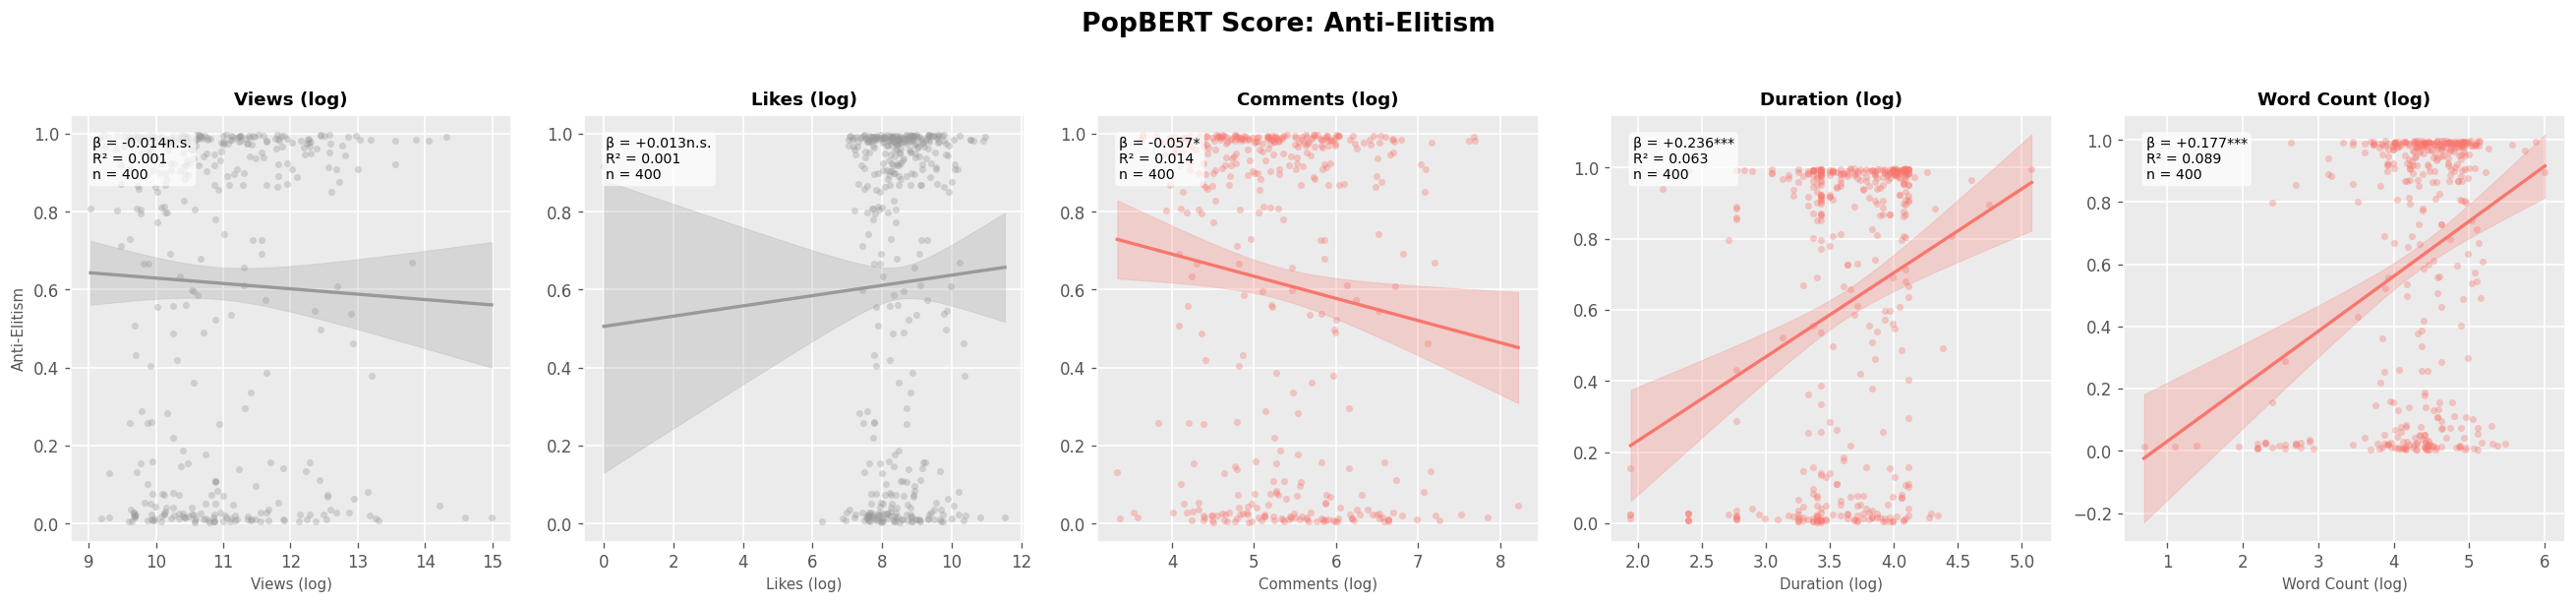

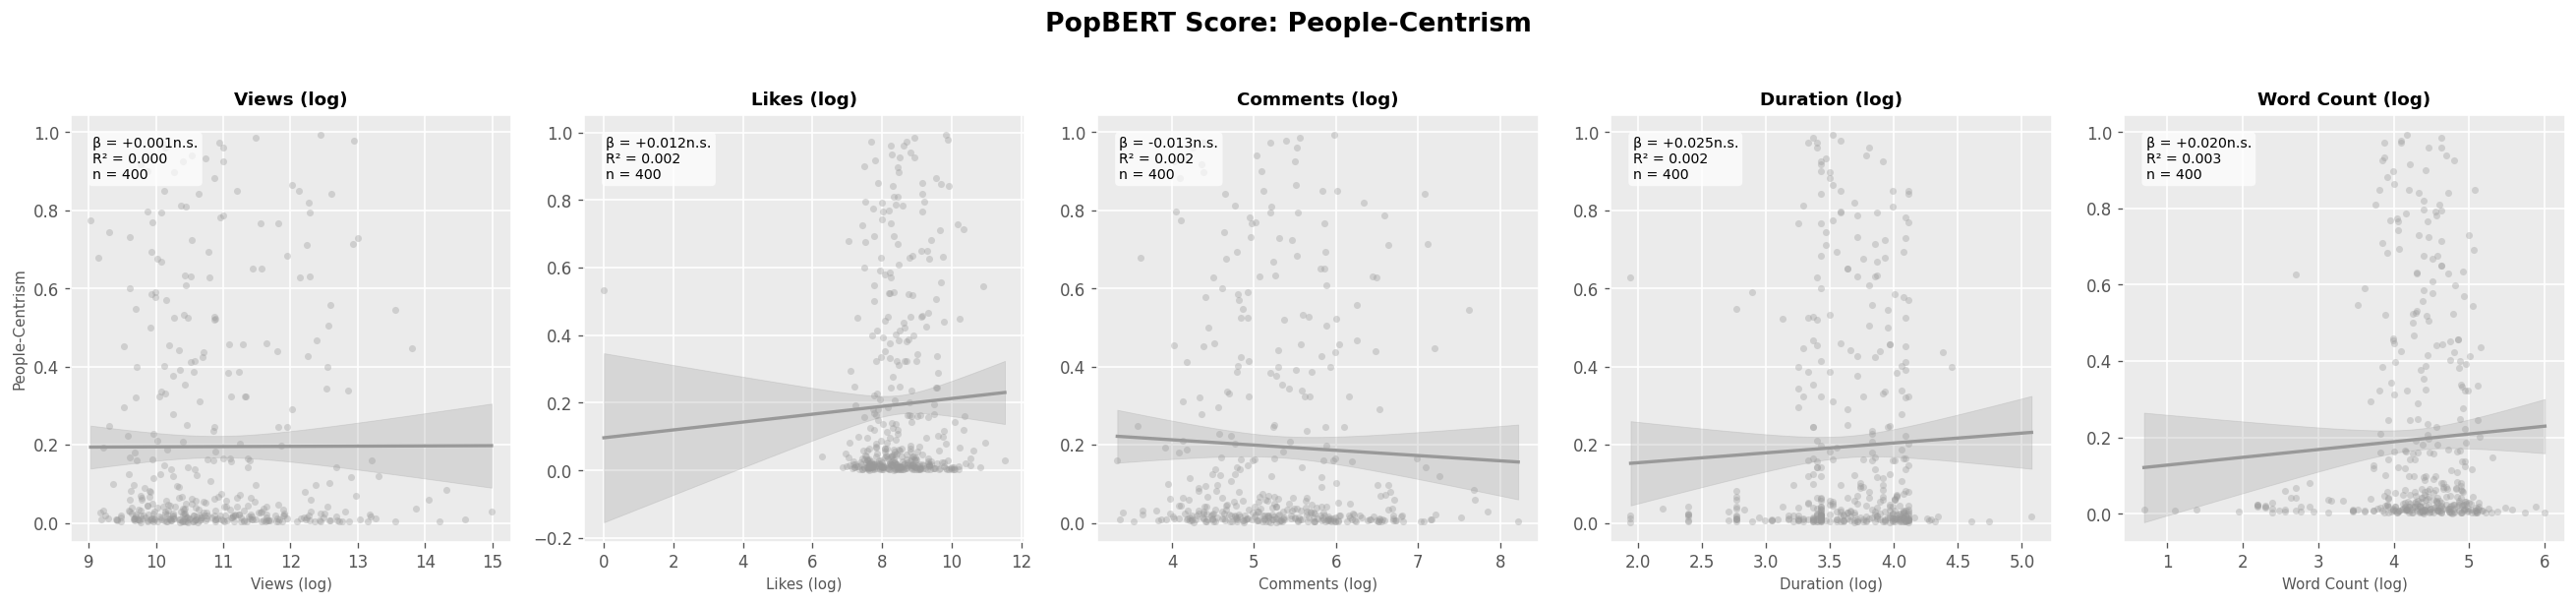

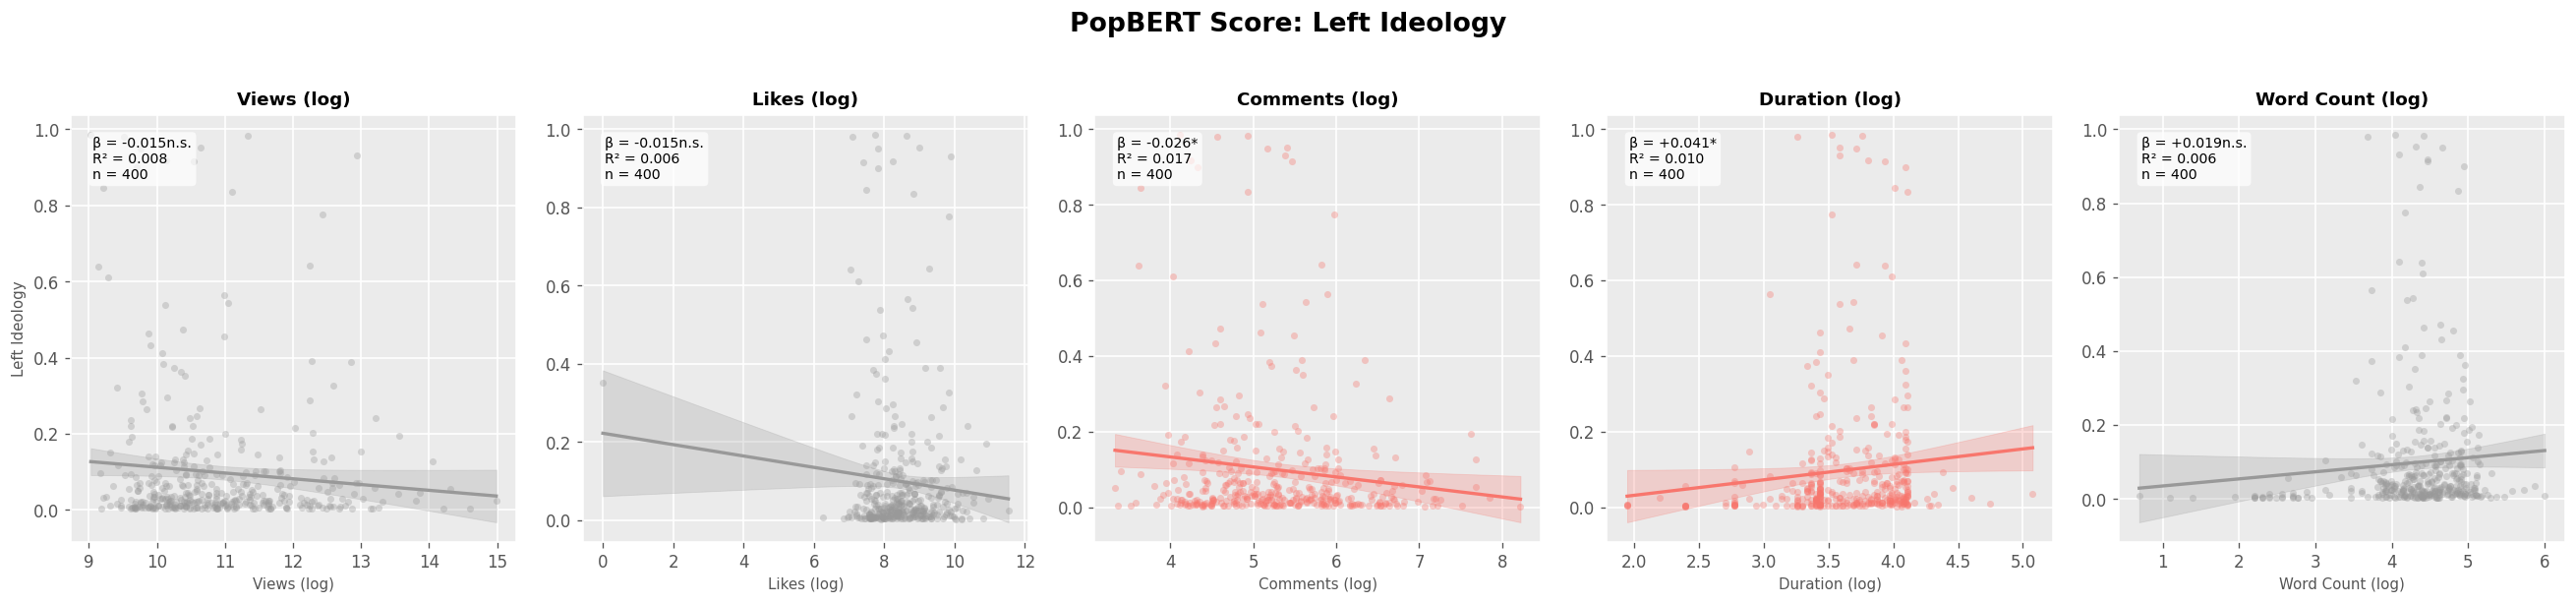

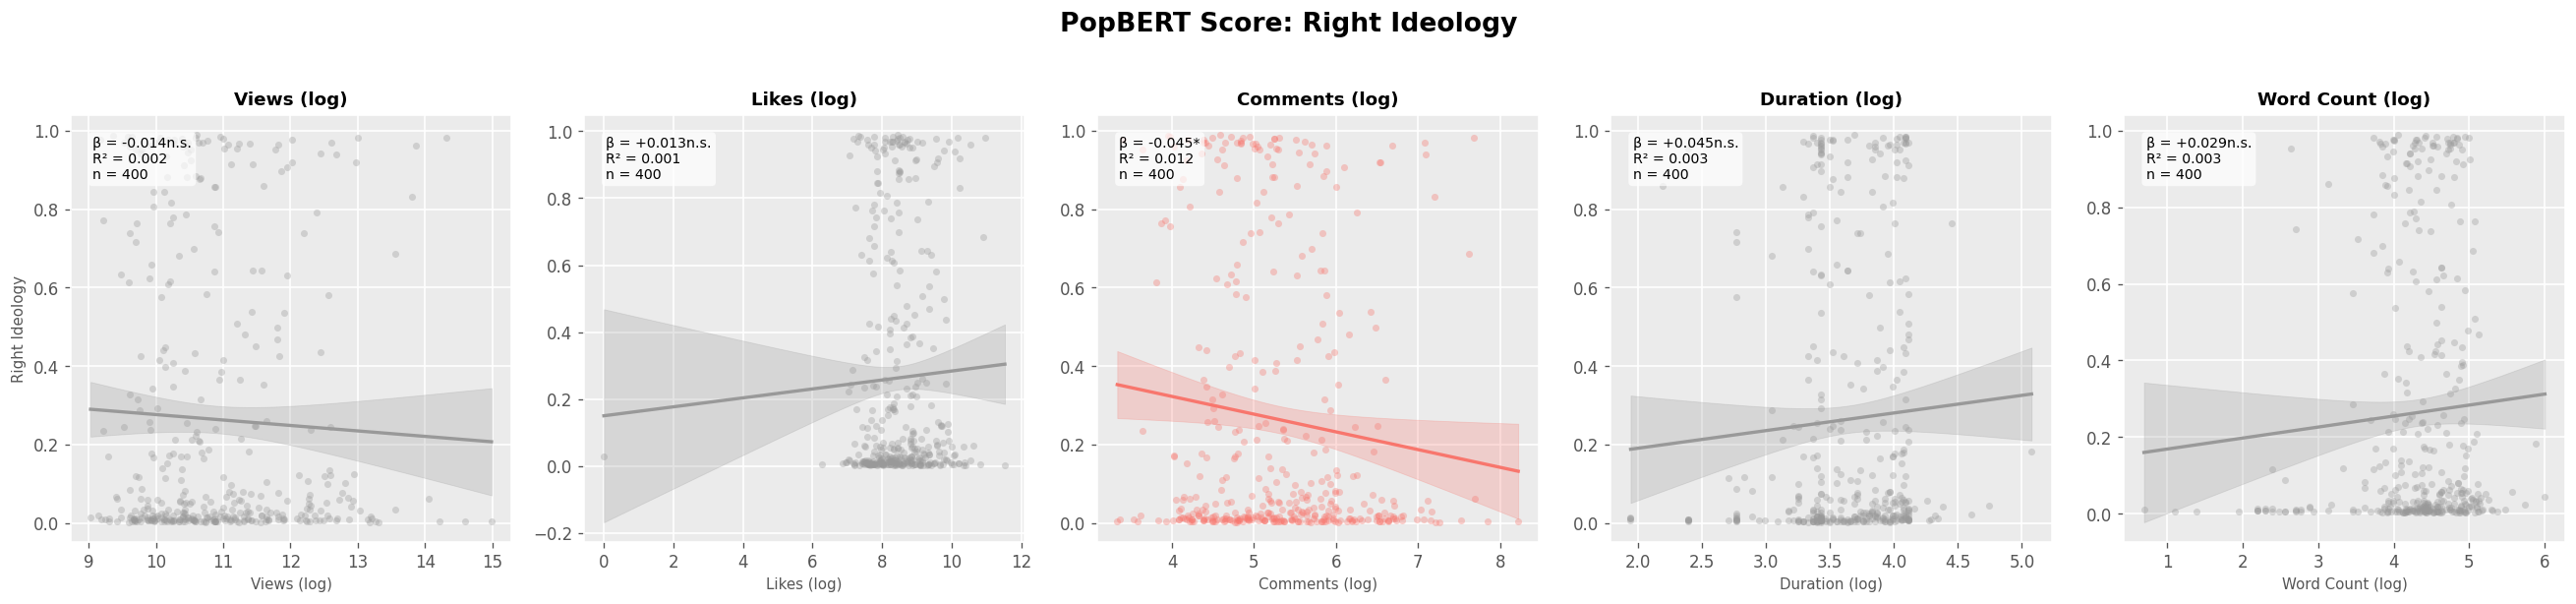

In [7]:
# ============================================================
# SCATTERPLOTS — One grid per dimension (5 predictors each)
# ============================================================

def plot_dimension(dim_label, dim_col, results, df):
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(f'PopBERT Score: {dim_label}', fontsize=16, fontweight='bold', y=1.02)

    for ax, (pred_label, pred_col) in zip(axes, PREDICTORS.items()):
        subset = df[[dim_col, pred_col]].dropna()
        x = subset[pred_col]
        y = subset[dim_col]

        r = results[dim_label][pred_label]
        p = r['pvalue']
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        color = COLORS[0] if p < 0.05 else '#999999'

        # Scatter
        ax.scatter(x, y, alpha=0.35, s=18, color=color, linewidths=0)

        # Regression line + CI
        x_sorted = np.linspace(x.min(), x.max(), 300)
        model = r['model']
        pred = model.get_prediction(sm.add_constant(
            pd.DataFrame({pred_col: x_sorted})
        ))
        pred_df = pred.summary_frame(alpha=0.05)

        ax.plot(x_sorted, pred_df['mean'], color=color, linewidth=2)
        ax.fill_between(
            x_sorted,
            pred_df['mean_ci_lower'],
            pred_df['mean_ci_upper'],
            alpha=0.25, color=color
        )

        # Annotations
        ax.set_title(pred_label, fontsize=11, fontweight='bold')
        ax.set_xlabel(pred_label, fontsize=9)
        ax.set_ylabel(dim_label if ax == axes[0] else '', fontsize=9)
        ax.annotate(
            f'β = {r["beta"]:+.3f}{stars}\nR² = {r["r2"]:.3f}\nn = {r["n"]}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            va='top', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
        )

    plt.tight_layout()
    plt.savefig(f'popbert_{dim_label.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


for dim_label, dim_col in BERT_DIMS.items():
    plot_dimension(dim_label, dim_col, results, df)


  Dependent Variable: Anti-Elitism (raw predictors)

  ~ Views
    β = -0.000000  p = 0.1718  R² = 0.0047  n = 400

  ~ Likes
    β = -0.000000  p = 0.8596  R² = 0.0001  n = 400

  ~ Comments
    β = -0.000132  p = 0.0191*  R² = 0.0137  n = 400

  ~ Duration
    β = +0.005625  p = 0.0000***  R² = 0.0496  n = 400

  ~ Word Count
    β = +0.001812  p = 0.0000***  R² = 0.0454  n = 400

  Dependent Variable: People-Centrism (raw predictors)

  ~ Views
    β = -0.000000  p = 0.4412  R² = 0.0015  n = 400

  ~ Likes
    β = +0.000000  p = 0.7966  R² = 0.0002  n = 400

  ~ Comments
    β = -0.000044  p = 0.2375  R² = 0.0035  n = 400

  ~ Duration
    β = -0.000184  p = 0.8271  R² = 0.0001  n = 400

  ~ Word Count
    β = -0.000314  p = 0.2698  R² = 0.0031  n = 400

  Dependent Variable: Left Ideology (raw predictors)

  ~ Views
    β = -0.000000  p = 0.3703  R² = 0.0020  n = 400

  ~ Likes
    β = -0.000001  p = 0.5130  R² = 0.0011  n = 400

  ~ Comments
    β = -0.000053  p = 0.0298*  R² = 0

,Dimension,Predictor,β,p-value,Sig.,R²,n
0,Anti-Elitism,Views,-0.000000,0.1718,,0.0047,400
1,Anti-Elitism,Likes,-0.000000,0.8596,,0.0001,400
2,Anti-Elitism,Comments,-0.000132,0.0191,*,0.0137,400
3,Anti-Elitism,Duration,+0.005625,0.0000,***,0.0496,400
4,Anti-Elitism,Word Count,+0.001812,0.0000,***,0.0454,400
5,People-Centrism,Views,-0.000000,0.4412,,0.0015,400
6,People-Centrism,Likes,+0.000000,0.7966,,0.0002,400
7,People-Centrism,Comments,-0.000044,0.2375,,0.0035,400
8,People-Centrism,Duration,-0.000184,0.8271,,0.0001,400
9,People-Centrism,Word Count,-0.000314,0.2698,,0.0031,400


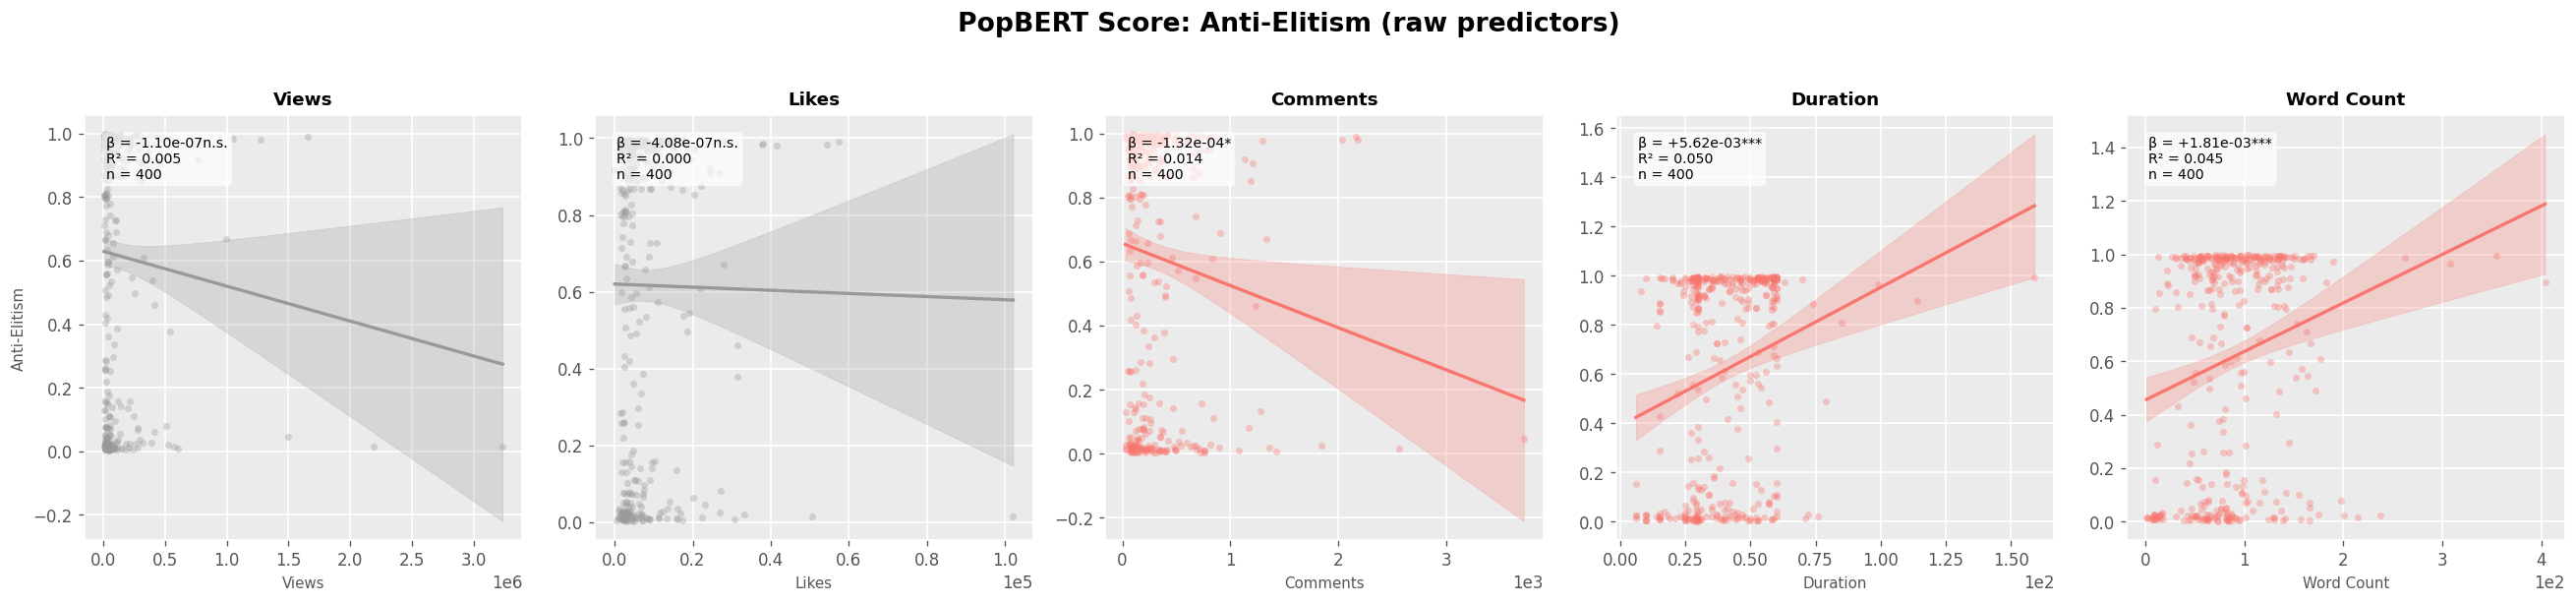

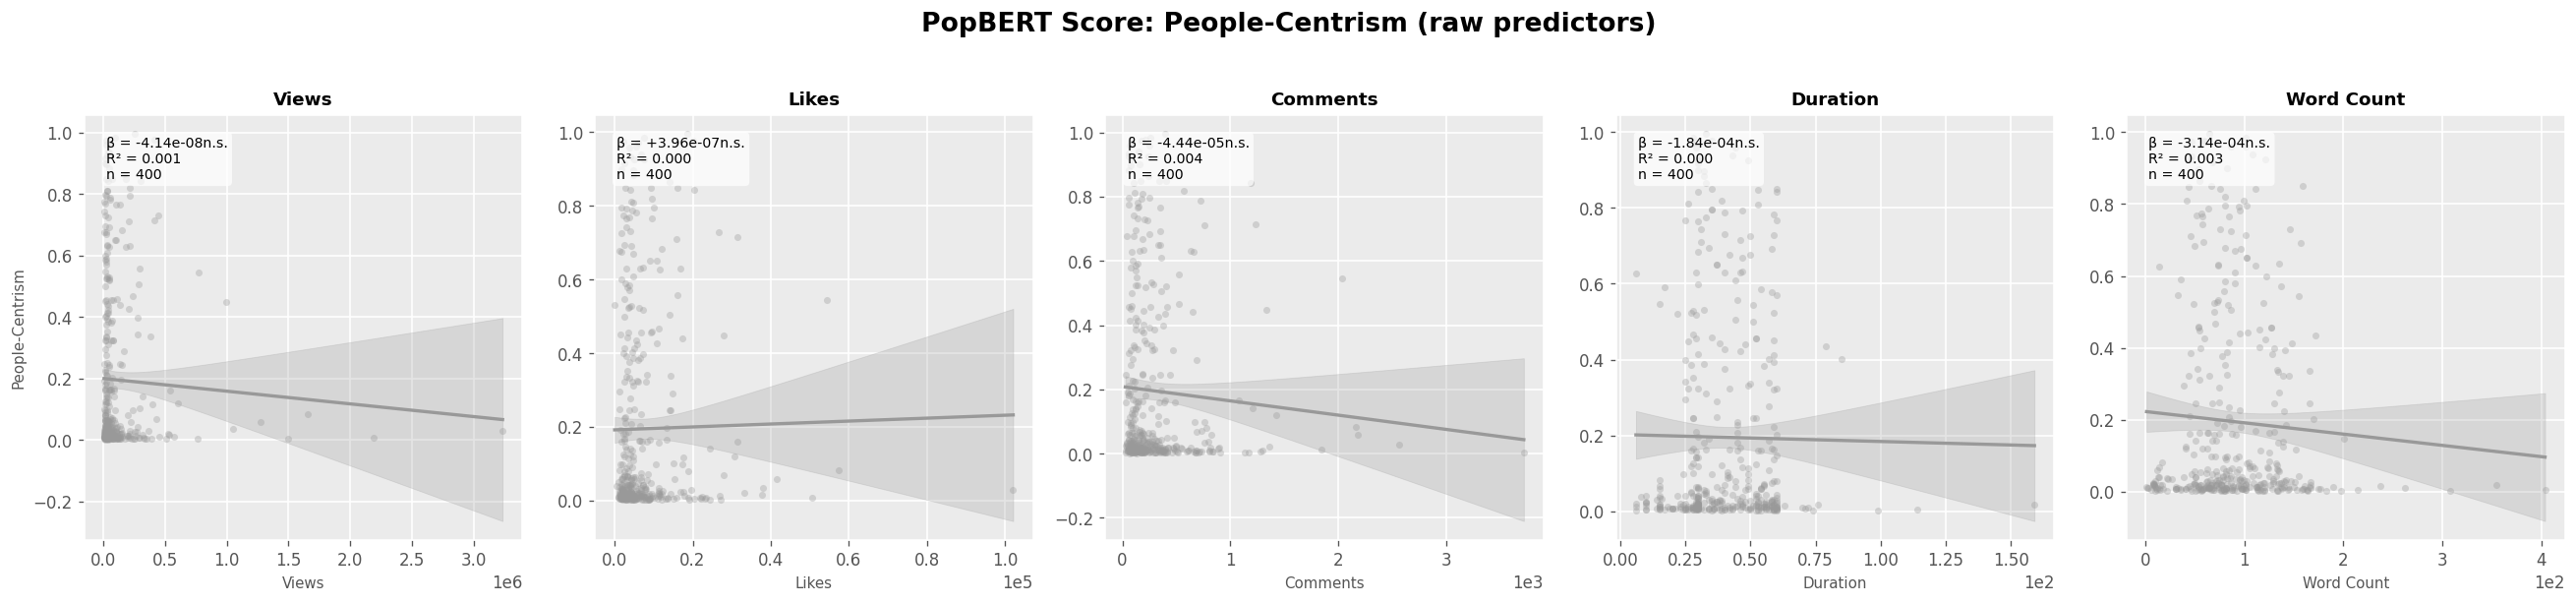

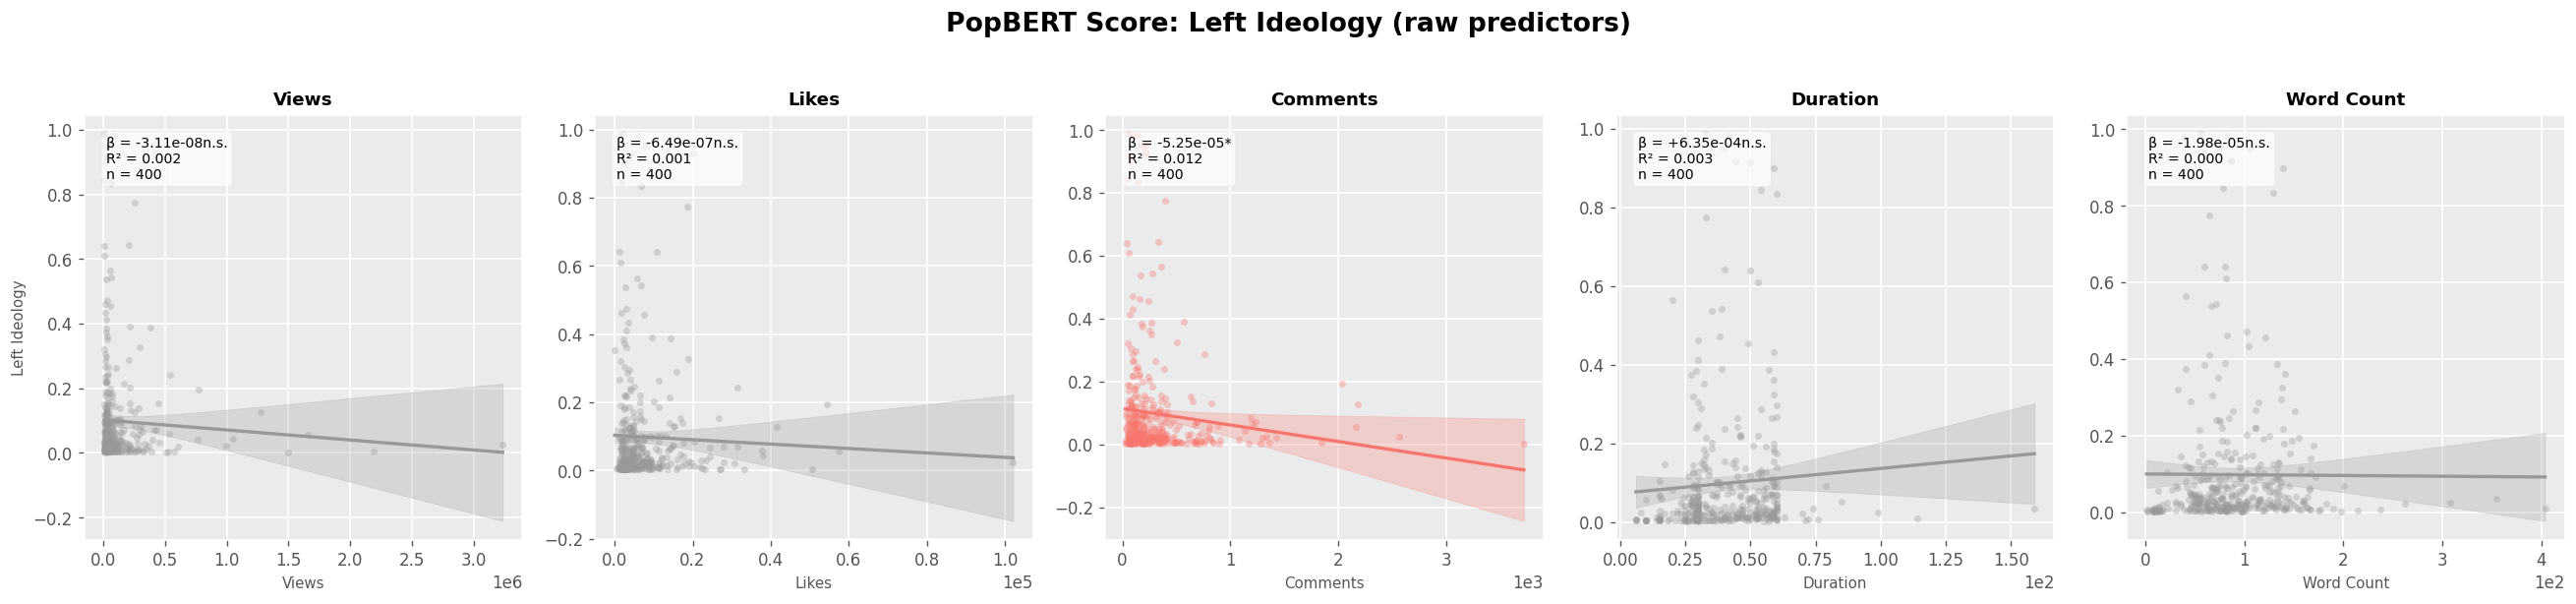

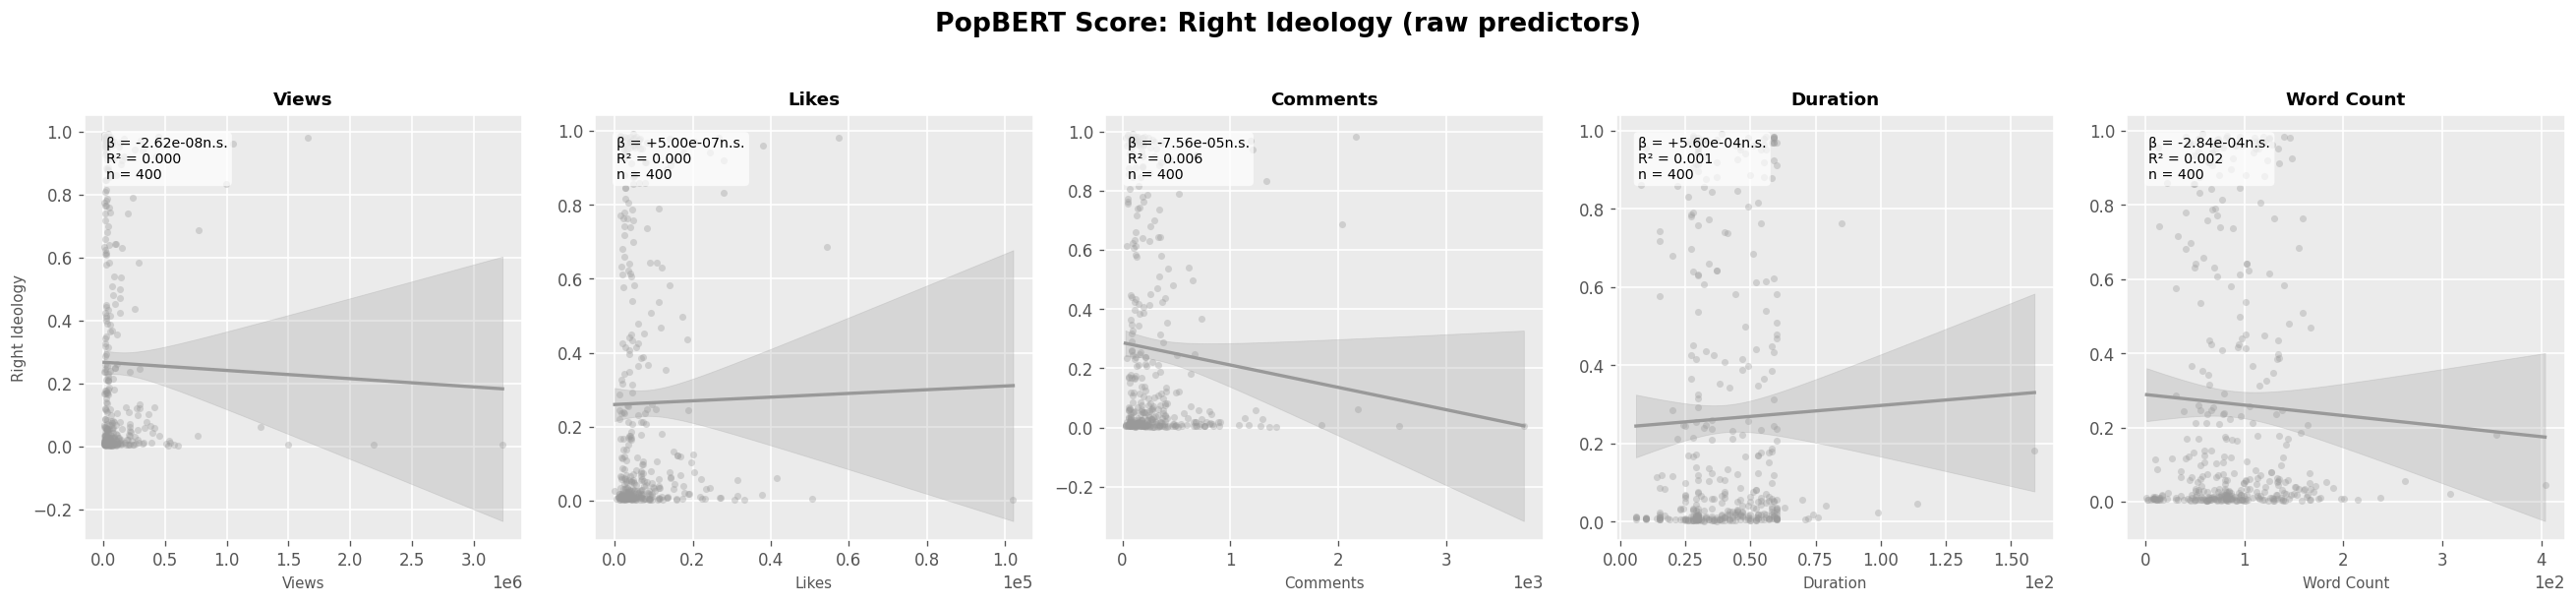

In [8]:
# ============================================================
# REGRESSIONS — Raw (non-logged) predictors
# ============================================================

RAW_PREDICTORS = {
    'Views':      'view_count',
    'Likes':      'like_count',
    'Comments':   'comment_count',
    'Duration':   'duration_seconds',
    'Word Count': 'word_count',
}

results_raw = {}

for dim_label, dim_col in BERT_DIMS.items():
    results_raw[dim_label] = {}
    print(f"\n{'='*60}")
    print(f"  Dependent Variable: {dim_label} (raw predictors)")
    print(f"{'='*60}")

    for pred_label, pred_col in RAW_PREDICTORS.items():
        subset = df[[dim_col, pred_col]].dropna()

        X = sm.add_constant(subset[pred_col])
        y = subset[dim_col]
        model = sm.OLS(y, X).fit()

        results_raw[dim_label][pred_label] = {
            'model':  model,
            'n':      len(subset),
            'beta':   model.params[pred_col],
            'pvalue': model.pvalues[pred_col],
            'r2':     model.rsquared,
        }

        p = model.pvalues[pred_col]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"\n  ~ {pred_label}")
        print(f"    β = {model.params[pred_col]:+.6f}  "
              f"p = {p:.4f}{stars}  "
              f"R² = {model.rsquared:.4f}  "
              f"n = {len(subset)}")

# ============================================================
# SUMMARY TABLE — Raw
# ============================================================

summary_rows_raw = []
for dim_label in BERT_DIMS:
    for pred_label in RAW_PREDICTORS:
        r = results_raw[dim_label][pred_label]
        p = r['pvalue']
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        summary_rows_raw.append({
            'Dimension': dim_label,
            'Predictor': pred_label,
            'β':         round(r['beta'], 6),
            'p-value':   round(r['pvalue'], 4),
            'Sig.':      stars,
            'R²':        round(r['r2'], 4),
            'n':         r['n'],
        })

summary_df_raw = pd.DataFrame(summary_rows_raw)
print("\nFull results table (raw predictors):")
display(summary_df_raw.style
    .background_gradient(subset=['β'], cmap='RdBu_r')
    .background_gradient(subset=['R²'], cmap='Greens')
    .format({'β': '{:+.6f}', 'p-value': '{:.4f}', 'R²': '{:.4f}'})
)

# ============================================================
# SCATTERPLOTS — Raw predictors, one grid per dimension
# ============================================================

for dim_label, dim_col in BERT_DIMS.items():
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(f'PopBERT Score: {dim_label} (raw predictors)', fontsize=16, fontweight='bold', y=1.02)

    for ax, (pred_label, pred_col) in zip(axes, RAW_PREDICTORS.items()):
        subset = df[[dim_col, pred_col]].dropna()
        x = subset[pred_col]
        y = subset[dim_col]

        r = results_raw[dim_label][pred_label]
        p = r['pvalue']
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        color = COLORS[0] if p < 0.05 else '#999999'

        ax.scatter(x, y, alpha=0.35, s=18, color=color, linewidths=0)

        x_sorted = np.linspace(x.min(), x.max(), 300)
        pred = r['model'].get_prediction(sm.add_constant(
            pd.DataFrame({pred_col: x_sorted})
        ))
        pred_df = pred.summary_frame(alpha=0.05)

        ax.plot(x_sorted, pred_df['mean'], color=color, linewidth=2)
        ax.fill_between(
            x_sorted,
            pred_df['mean_ci_lower'],
            pred_df['mean_ci_upper'],
            alpha=0.25, color=color
        )

        ax.set_title(pred_label, fontsize=11, fontweight='bold')
        ax.set_xlabel(pred_label, fontsize=9)
        ax.set_ylabel(dim_label if ax == axes[0] else '', fontsize=9)
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        ax.annotate(
            f'β = {r["beta"]:+.2e}{stars}\nR² = {r["r2"]:.3f}\nn = {r["n"]}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            va='top', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
        )

    plt.tight_layout()
    plt.savefig(f'popbert_{dim_label.lower().replace(" ", "_")}_raw.png',
                dpi=150, bbox_inches='tight')
    plt.show()

Initializing NUTS using jitter+adapt_diag...



  BAYESIAN REGRESSION — Log-transformed predictors

  Fitting: Anti-Elitism ~ Views (log) ...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


...

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


    β = -0.000286  95% HDI [-0.001021, +0.000396]  R̂ = 1.001  n = 400

Bayesian Summary — Log predictors:


,Dimension,Predictor,β (mean),95% HDI low,95% HDI high,Excl. zero,R̂,n
0,Anti-Elitism,Views (log),-0.0136,-0.0510,+0.0227,,1.000,400
1,Anti-Elitism,Likes (log),+0.0129,-0.0294,+0.0560,,1.000,400
2,Anti-Elitism,Comments (log),-0.0559,-0.1014,-0.0082,✓,1.001,400
3,Anti-Elitism,Duration (log),+0.2337,+0.1445,+0.3197,✓,1.000,400
4,Anti-Elitism,Word Count (log),+0.1752,+0.1230,+0.2335,✓,1.000,400
5,People-Centrism,Views (log),+0.0006,-0.0226,+0.0265,,1.001,400
6,People-Centrism,Likes (log),+0.0118,-0.0170,+0.0407,,1.000,400
7,People-Centrism,Comments (log),-0.0136,-0.0445,+0.0174,,1.001,400
8,People-Centrism,Duration (log),+0.0253,-0.0351,+0.0859,,1.000,400
9,People-Centrism,Word Count (log),+0.0205,-0.0161,+0.0623,,1.001,400



Bayesian Summary — Raw predictors:


,Dimension,Predictor,β (mean),95% HDI low,95% HDI high,Excl. zero,R̂,n
0,Anti-Elitism,Views,-0.000000,-0.000000,+0.000000,,1.001,400
1,Anti-Elitism,Likes,-0.000000,-0.000005,+0.000004,,1.000,400
2,Anti-Elitism,Comments,-0.000129,-0.000239,-0.000019,✓,1.001,400
3,Anti-Elitism,Duration,+0.005553,+0.003160,+0.007918,✓,1.000,400
4,Anti-Elitism,Word Count,+0.001794,+0.001014,+0.002600,✓,1.001,400
5,People-Centrism,Views,-0.000000,-0.000000,+0.000000,,1.001,400
6,People-Centrism,Likes,+0.000000,-0.000003,+0.000003,,1.000,400
7,People-Centrism,Comments,-0.000044,-0.000119,+0.000025,,1.001,400
8,People-Centrism,Duration,-0.000177,-0.001870,+0.001426,,1.001,400
9,People-Centrism,Word Count,-0.000312,-0.000856,+0.000230,,1.001,400


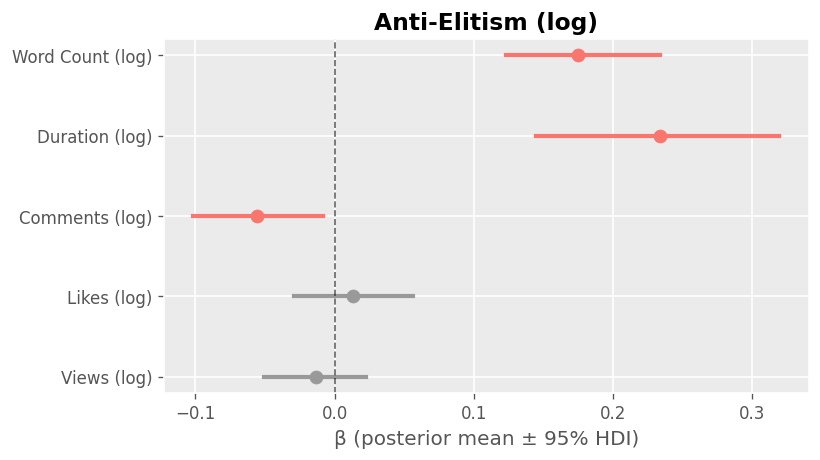

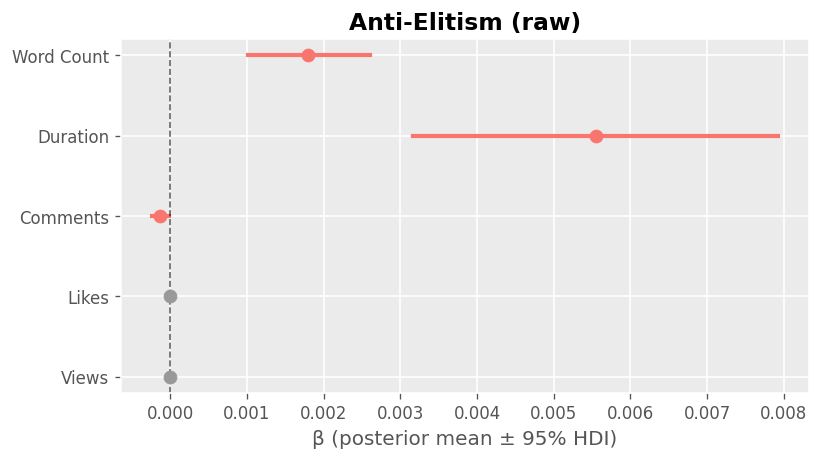

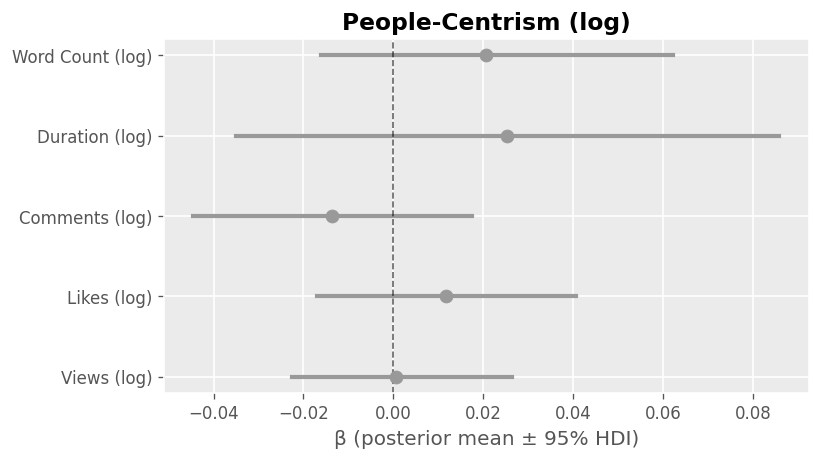

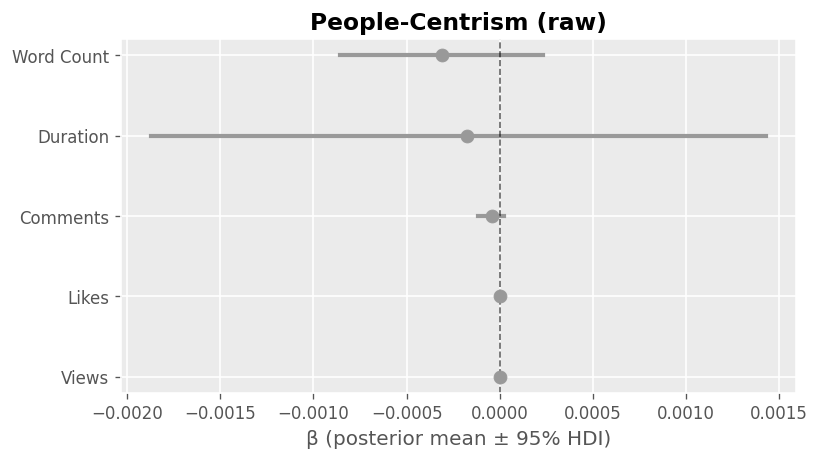

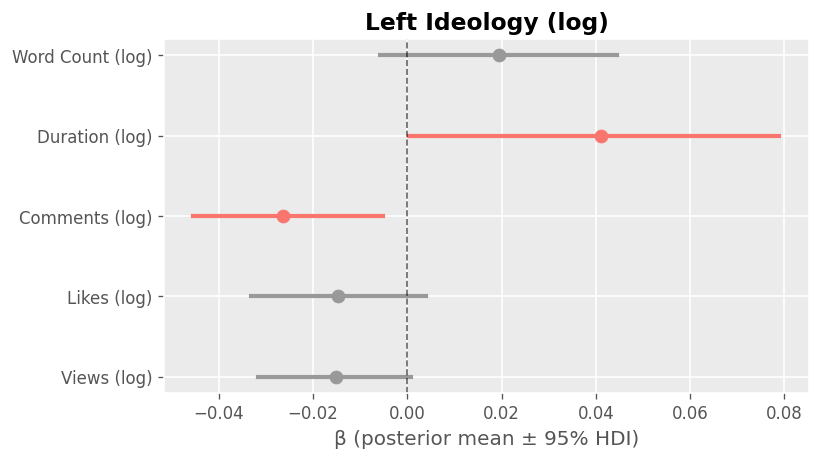

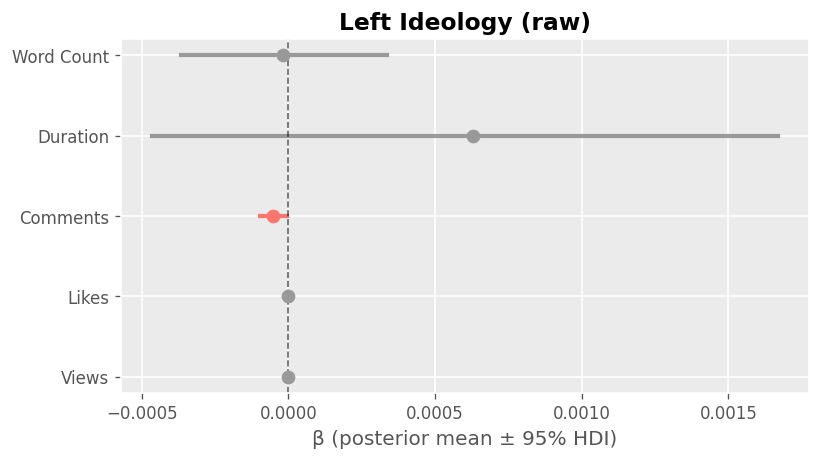

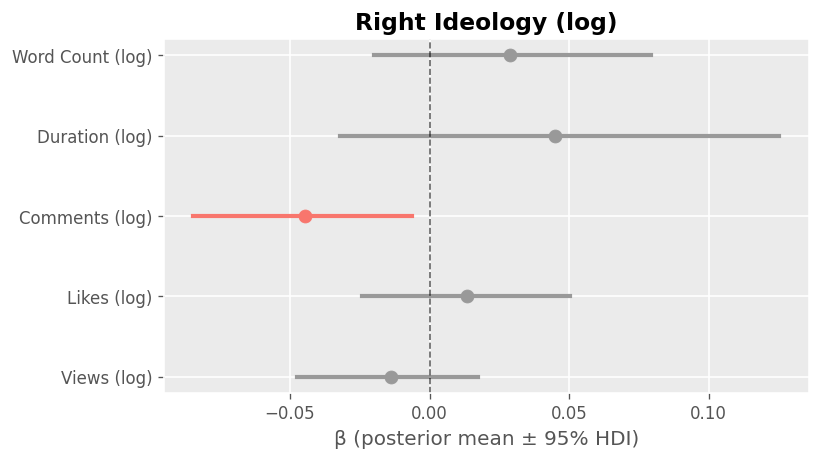

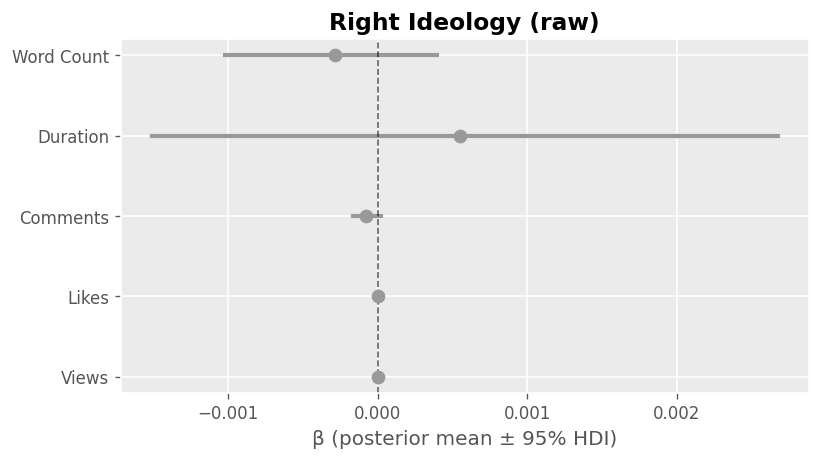

In [9]:
# ============================================================
# BAYESIAN LINEAR REGRESSION
# ============================================================

# pip install pymc --break-system-packages
import pymc as pm
import arviz as az

SAMPLE_KWARGS = dict(draws=2000, tune=1000, chains=4,
                     target_accept=0.9, random_seed=42, progressbar=True)

results_bayes     = {}  # logged predictors
results_bayes_raw = {}  # raw predictors

def run_bayesian(dim_col, pred_col, subset):
    """Fit a Bayesian OLS with weakly informative priors."""
    x_data = subset[pred_col].values
    y_data = subset[dim_col].values

    # Standardize x for sampling efficiency, back-transform after
    x_mean, x_std = x_data.mean(), x_data.std()
    x_scaled = (x_data - x_mean) / x_std

    with pm.Model() as model:
        # Weakly informative priors
        alpha = pm.Normal('alpha', mu=y_data.mean(), sigma=0.5)
        beta  = pm.Normal('beta',  mu=0, sigma=0.2)
        sigma = pm.HalfNormal('sigma', sigma=0.5)

        mu = alpha + beta * x_scaled
        likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y_data)

        trace = pm.sample(**SAMPLE_KWARGS)

    # Back-transform beta to original scale
    beta_orig = trace.posterior['beta'].values / x_std

    return {
        'trace':       trace,
        'beta_mean':   float(beta_orig.mean()),
        'beta_sd':     float(beta_orig.std()),
        'hdi_low':     float(az.hdi(beta_orig.flatten(), hdi_prob=0.95)[0]),
        'hdi_high':    float(az.hdi(beta_orig.flatten(), hdi_prob=0.95)[1]),
        'r_hat':       float(az.rhat(trace)['beta'].values),
        'n':           len(subset),
    }


# --- Logged predictors ---
print("\n" + "="*60)
print("  BAYESIAN REGRESSION — Log-transformed predictors")
print("="*60)

for dim_label, dim_col in BERT_DIMS.items():
    results_bayes[dim_label] = {}
    for pred_label, pred_col in PREDICTORS.items():
        print(f"\n  Fitting: {dim_label} ~ {pred_label} ...")
        subset = df[[dim_col, pred_col]].dropna()
        results_bayes[dim_label][pred_label] = run_bayesian(dim_col, pred_col, subset)
        r = results_bayes[dim_label][pred_label]
        print(f"    β = {r['beta_mean']:+.4f}  "
              f"95% HDI [{r['hdi_low']:+.4f}, {r['hdi_high']:+.4f}]  "
              f"R̂ = {r['r_hat']:.3f}  n = {r['n']}")


# --- Raw predictors ---
print("\n" + "="*60)
print("  BAYESIAN REGRESSION — Raw predictors")
print("="*60)

for dim_label, dim_col in BERT_DIMS.items():
    results_bayes_raw[dim_label] = {}
    for pred_label, pred_col in RAW_PREDICTORS.items():
        print(f"\n  Fitting: {dim_label} ~ {pred_label} ...")
        subset = df[[dim_col, pred_col]].dropna()
        results_bayes_raw[dim_label][pred_label] = run_bayesian(dim_col, pred_col, subset)
        r = results_bayes_raw[dim_label][pred_label]
        print(f"    β = {r['beta_mean']:+.6f}  "
              f"95% HDI [{r['hdi_low']:+.6f}, {r['hdi_high']:+.6f}]  "
              f"R̂ = {r['r_hat']:.3f}  n = {r['n']}")


# ============================================================
# SUMMARY TABLE — Bayesian (logged)
# ============================================================

def bayes_summary_table(results_b, pred_dict, fmt='.4f'):
    summary_rows_b = []
    for dim_label in BERT_DIMS:
        for pred_label in pred_dict:
            r = results_b[dim_label][pred_label]
            # Credible interval excludes zero?
            sig = '✓' if (r['hdi_low'] > 0 or r['hdi_high'] < 0) else ''
            summary_rows_b.append({
                'Dimension':  dim_label,
                'Predictor':  pred_label,
                'β (mean)':   round(r['beta_mean'], 6),
                '95% HDI low':  round(r['hdi_low'], 6),
                '95% HDI high': round(r['hdi_high'], 6),
                'Excl. zero': sig,
                'R̂':          round(r['r_hat'], 3),
                'n':          r['n'],
            })
    df_b = pd.DataFrame(summary_rows_b)
    display(df_b.style
        .background_gradient(subset=['β (mean)'], cmap='RdBu_r')
        .format({'β (mean)': f'{{:+{fmt}}}',
                 '95% HDI low': f'{{:+{fmt}}}',
                 '95% HDI high': f'{{:+{fmt}}}',
                 'R̂': '{:.3f}'})
    )
    return df_b

print("\nBayesian Summary — Log predictors:")
bayes_log_df = bayes_summary_table(results_bayes, PREDICTORS, fmt='.4f')

print("\nBayesian Summary — Raw predictors:")
bayes_raw_df = bayes_summary_table(results_bayes_raw, RAW_PREDICTORS, fmt='.6f')


# ============================================================
# COEFFICIENT PLOTS (Forest plots) — one per dimension
# ============================================================

def plot_forest(results_b, pred_dict, dim_label, title_suffix=''):
    pred_labels = list(pred_dict.keys())
    betas  = [results_b[dim_label][p]['beta_mean'] for p in pred_labels]
    lows   = [results_b[dim_label][p]['hdi_low']   for p in pred_labels]
    highs  = [results_b[dim_label][p]['hdi_high']  for p in pred_labels]
    colors = [COLORS[0] if (l > 0 or h < 0) else '#999999'
              for l, h in zip(lows, highs)]

    fig, ax = plt.subplots(figsize=(7, 4))
    y_pos = range(len(pred_labels))

    for i, (b, lo, hi, c) in enumerate(zip(betas, lows, highs, colors)):
        ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
        ax.scatter(b, i, color=c, s=60, zorder=5)

    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(pred_labels)
    ax.set_xlabel('β (posterior mean ± 95% HDI)')
    ax.set_title(f'{dim_label}{title_suffix}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'bayes_forest_{dim_label.lower().replace(" ", "_")}{title_suffix.strip()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

for dim_label in BERT_DIMS:
    plot_forest(results_bayes,     PREDICTORS,     dim_label, ' (log)')
    plot_forest(results_bayes_raw, RAW_PREDICTORS, dim_label, ' (raw)')

<Axes: >

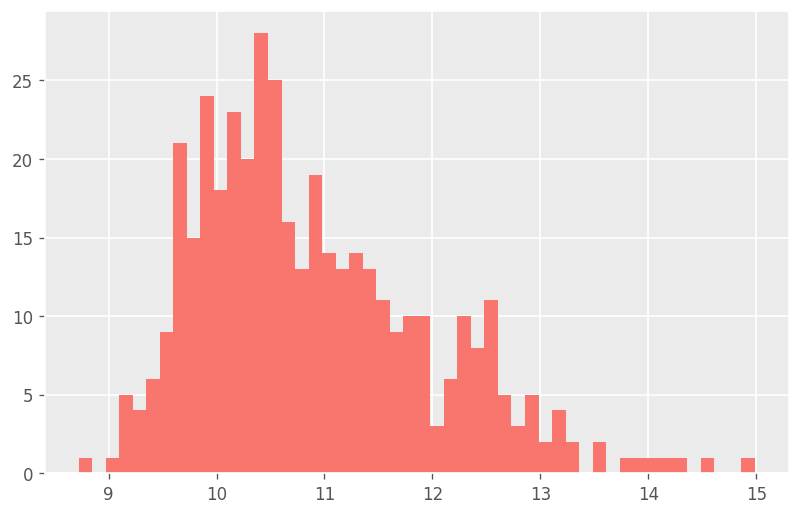

In [10]:
df['log_view_count'].hist(bins=50)

In [11]:
df['log_view_count_sq'] = df['log_view_count'] ** 2

QUADRATIC REGRESSION: log_view_count + log_view_count²

  Anti-Elitism
    β_linear = +0.1408  (p = 0.6502)
    β_sq     = -0.0068  (p = 0.6179) n.s.
    R² = 0.0019  |  Adj. R² = -0.0031
    Shape: Inverted-U (∩)  |  Vertex at log(views) = 10.36  (~31,616 views)

  People-Centrism
    β_linear = +0.1455  (p = 0.4824)
    β_sq     = -0.0064  (p = 0.4834) n.s.
    R² = 0.0012  |  Adj. R² = -0.0038
    Shape: Inverted-U (∩)  |  Vertex at log(views) = 11.43  (~91,607 views)

  Left Ideology
    β_linear = -0.2869  (p = 0.0305)
    β_sq     = +0.0119  (p = 0.0400) *
    R² = 0.0188  |  Adj. R² = 0.0138
    Shape: U-shaped (∪)  |  Vertex at log(views) = 12.01  (~164,522 views)

  Right Ideology
    β_linear = -0.1118  (p = 0.6709)
    β_sq     = +0.0043  (p = 0.7093) n.s.
    R² = 0.0021  |  Adj. R² = -0.0029
    Shape: U-shaped (∪)  |  Vertex at log(views) = 12.99  (~438,621 views)


MODEL COMPARISON — Linear vs Quadratic R²
Dimension               R² linear   R² quadratic      ΔR²
-------

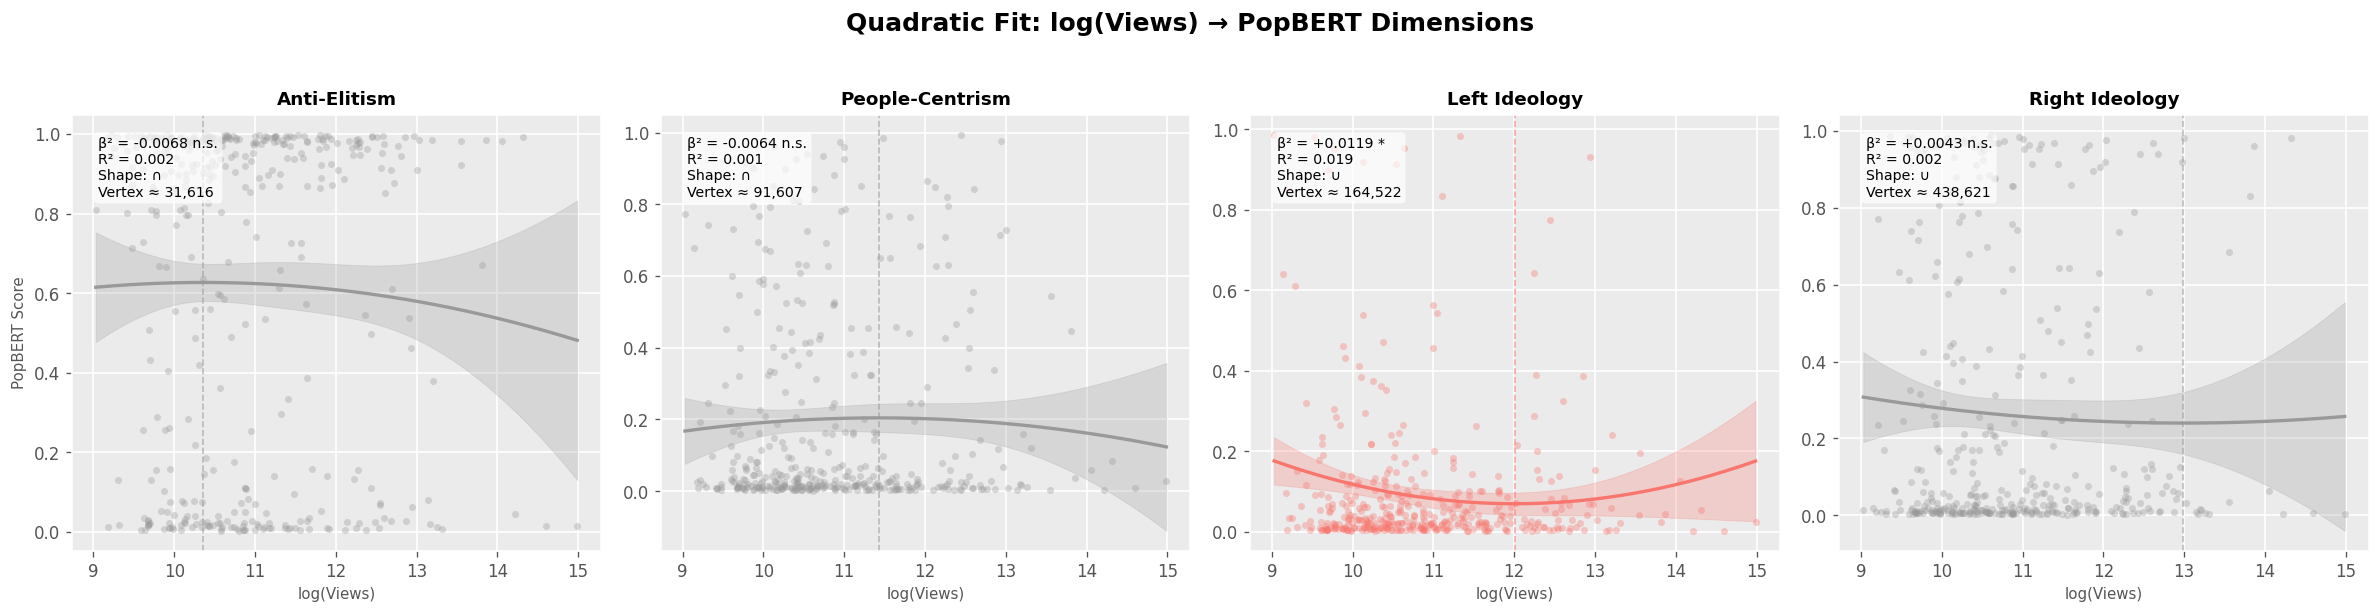

In [12]:
# ============================================================
# QUADRATIC REGRESSION — Views vs Populism
# ============================================================

df['log_view_count_sq'] = df['log_view_count'] ** 2

results_quad = {}

print("QUADRATIC REGRESSION: log_view_count + log_view_count²")
print("="*60)

for dim_label, dim_col in BERT_DIMS.items():
    subset = df[[dim_col, 'log_view_count', 'log_view_count_sq']].dropna()

    X = sm.add_constant(subset[['log_view_count', 'log_view_count_sq']])
    y = subset[dim_col]
    model = sm.OLS(y, X).fit()

    results_quad[dim_label] = {
        'model':      model,
        'beta_lin':   model.params['log_view_count'],
        'beta_sq':    model.params['log_view_count_sq'],
        'p_lin':      model.pvalues['log_view_count'],
        'p_sq':       model.pvalues['log_view_count_sq'],
        'r2':         model.rsquared,
        'r2_adj':     model.rsquared_adj,
        'n':          len(subset),
    }

    p_sq = model.pvalues['log_view_count_sq']
    stars_sq = '***' if p_sq < 0.001 else '**' if p_sq < 0.01 else '*' if p_sq < 0.05 else 'n.s.'

    # Vertex of the parabola: x* = -β_lin / (2 * β_sq)
    vertex = -model.params['log_view_count'] / (2 * model.params['log_view_count_sq'])
    direction = 'U-shaped (∪)' if model.params['log_view_count_sq'] > 0 else 'Inverted-U (∩)'

    print(f"\n  {dim_label}")
    print(f"    β_linear = {model.params['log_view_count']:+.4f}  (p = {model.pvalues['log_view_count']:.4f})")
    print(f"    β_sq     = {model.params['log_view_count_sq']:+.4f}  (p = {p_sq:.4f}) {stars_sq}")
    print(f"    R² = {model.rsquared:.4f}  |  Adj. R² = {model.rsquared_adj:.4f}")
    print(f"    Shape: {direction}  |  Vertex at log(views) = {vertex:.2f}  (~{int(np.expm1(vertex)):,} views)")


# ============================================================
# COMPARE: Linear R² vs Quadratic R²
# ============================================================

print("\n\nMODEL COMPARISON — Linear vs Quadratic R²")
print("="*60)
print(f"{'Dimension':<20} {'R² linear':>12} {'R² quadratic':>14} {'ΔR²':>8}")
print("-"*60)
for dim_label in BERT_DIMS:
    r2_lin  = results[dim_label]['Views (log)']['r2']
    r2_quad = results_quad[dim_label]['r2']
    delta   = r2_quad - r2_lin
    print(f"{dim_label:<20} {r2_lin:>12.4f} {r2_quad:>14.4f} {delta:>+8.4f}")


# ============================================================
# PLOTS — Quadratic fit with raw data
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Quadratic Fit: log(Views) → PopBERT Dimensions', fontsize=15, fontweight='bold', y=1.02)

for ax, (dim_label, dim_col) in zip(axes, BERT_DIMS.items()):
    subset = df[[dim_col, 'log_view_count']].dropna()
    x = subset['log_view_count']
    y = subset[dim_col]

    r  = results_quad[dim_label]
    p_sq = r['p_sq']
    color = COLORS[0] if p_sq < 0.05 else '#999999'

    # Scatter
    ax.scatter(x, y, alpha=0.35, s=18, color=color, linewidths=0)

    # Quadratic fit line + CI
    x_sorted = np.linspace(x.min(), x.max(), 300)
    pred = r['model'].get_prediction(sm.add_constant(
        pd.DataFrame({
            'log_view_count':    x_sorted,
            'log_view_count_sq': x_sorted ** 2
        })
    ))
    pred_df = pred.summary_frame(alpha=0.05)

    ax.plot(x_sorted, pred_df['mean'], color=color, linewidth=2)
    ax.fill_between(x_sorted, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                    alpha=0.25, color=color)

    # Vertex line
    vertex = -r['beta_lin'] / (2 * r['beta_sq'])
    ax.axvline(vertex, color=color, linewidth=1, linestyle='--', alpha=0.6)

    stars_sq = '***' if p_sq < 0.001 else '**' if p_sq < 0.01 else '*' if p_sq < 0.05 else 'n.s.'
    direction = '∪' if r['beta_sq'] > 0 else '∩'
    ax.annotate(
        f'β² = {r["beta_sq"]:+.4f} {stars_sq}\nR² = {r["r2"]:.3f}\nShape: {direction}\nVertex ≈ {int(np.expm1(vertex)):,}',
        xy=(0.05, 0.95), xycoords='axes fraction',
        va='top', ha='left', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

    ax.set_title(dim_label, fontsize=11, fontweight='bold')
    ax.set_xlabel('log(Views)', fontsize=9)
    ax.set_ylabel('PopBERT Score' if ax == axes[0] else '', fontsize=9)

plt.tight_layout()
plt.savefig('popbert_quadratic_views.png', dpi=150, bbox_inches='tight')
plt.show()

MULTIVARIATE OLS: All log-predictors simultaneously

  Anti-Elitism  (n=400, R²=0.1192, Adj.R²=0.1080)
  Predictor                     β         SE        t          p   Sig
  -----------------------------------------------------------------
  Views (log)             +0.0232     0.0355    0.655     0.5128      
  Likes (log)             +0.0430     0.0370    1.164     0.2452      
  Comments (log)          -0.1176     0.0338   -3.483     0.0006   ***
  Duration (log)          +0.0063     0.0788    0.080     0.9361      
  Word Count (log)        +0.1740     0.0493    3.529     0.0005   ***

  People-Centrism  (n=400, R²=0.0114, Adj.R²=-0.0011)
  Predictor                     β         SE        t          p   Sig
  -----------------------------------------------------------------
  Views (log)             -0.0012     0.0251   -0.049     0.9612      
  Likes (log)             +0.0331     0.0261    1.269     0.2050      
  Comments (log)          -0.0366     0.0239   -1.536     0.1254   

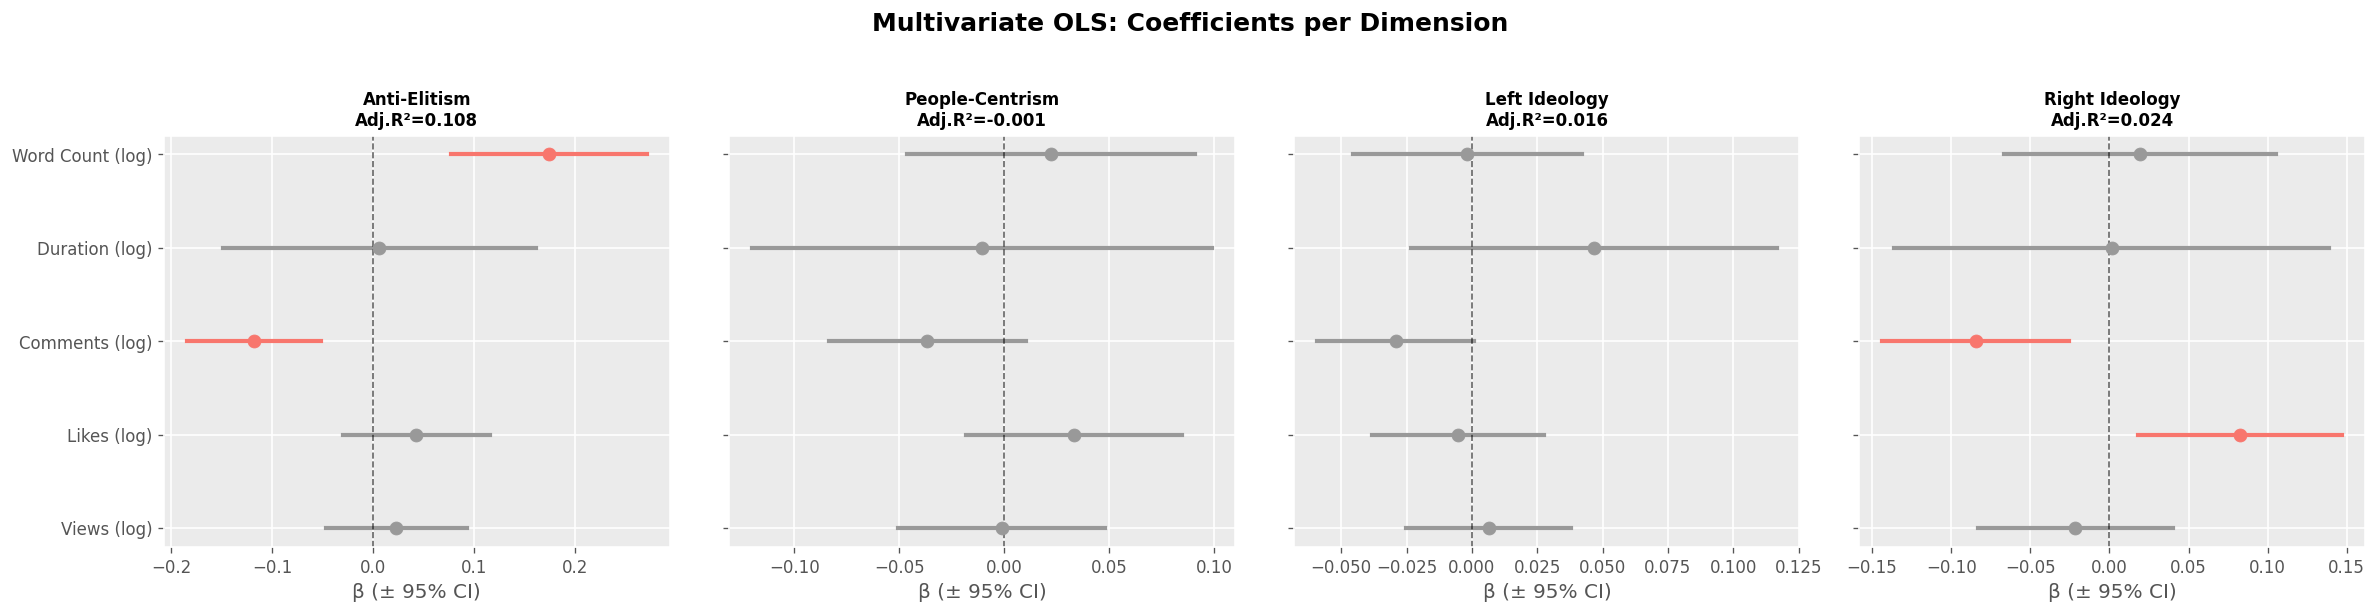

In [13]:
# ============================================================
# MULTIVARIATE OLS — All predictors combined
# ============================================================

results_multi = {}

print("MULTIVARIATE OLS: All log-predictors simultaneously")
print("="*60)

for dim_label, dim_col in BERT_DIMS.items():
    pred_cols = list(PREDICTORS.values())
    subset = df[[dim_col] + pred_cols].dropna()

    X = sm.add_constant(subset[pred_cols])
    y = subset[dim_col]
    model = sm.OLS(y, X).fit()

    results_multi[dim_label] = {
        'model': model,
        'n':     len(subset),
        'r2':    model.rsquared,
        'r2_adj': model.rsquared_adj,
    }

    print(f"\n  {dim_label}  (n={len(subset)}, R²={model.rsquared:.4f}, Adj.R²={model.rsquared_adj:.4f})")
    print(f"  {'Predictor':<20} {'β':>10} {'SE':>10} {'t':>8} {'p':>10} {'Sig':>5}")
    print(f"  {'-'*65}")
    for pred_label, pred_col in PREDICTORS.items():
        b  = model.params[pred_col]
        se = model.bse[pred_col]
        t  = model.tvalues[pred_col]
        p  = model.pvalues[pred_col]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {pred_label:<20} {b:>+10.4f} {se:>10.4f} {t:>8.3f} {p:>10.4f} {stars:>5}")


# ============================================================
# VARIANCE INFLATION FACTORS — check multicollinearity
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n\nVARIANCE INFLATION FACTORS (VIF)")
print("="*60)
print("  VIF > 5 = moderate collinearity, VIF > 10 = severe")
print(f"\n  {'Predictor':<20} {'VIF':>8}")
print(f"  {'-'*30}")

pred_cols = list(PREDICTORS.values())
subset_vif = df[pred_cols].dropna()
X_vif = sm.add_constant(subset_vif)

for i, pred_col in enumerate(pred_cols):
    vif = variance_inflation_factor(X_vif.values, i + 1)
    pred_label = list(PREDICTORS.keys())[i]
    flag = ' ⚠️' if vif > 5 else ''
    print(f"  {pred_label:<20} {vif:>8.3f}{flag}")


# ============================================================
# COMPARE: Bivariate R² vs Multivariate R²
# ============================================================

print("\n\nMODEL COMPARISON — Best Bivariate vs Multivariate Adj. R²")
print("="*60)
print(f"{'Dimension':<20} {'Best biv. R²':>14} {'Multi Adj.R²':>14} {'ΔAdj.R²':>10}")
print("-"*60)
for dim_label in BERT_DIMS:
    best_biv  = max(r['r2'] for r in results[dim_label].values())
    multi_adj = results_multi[dim_label]['r2_adj']
    delta     = multi_adj - best_biv
    print(f"{dim_label:<20} {best_biv:>14.4f} {multi_adj:>14.4f} {delta:>+10.4f}")


# ============================================================
# COEFFICIENT PLOT — Multivariate betas across dimensions
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Multivariate OLS: Coefficients per Dimension',
             fontsize=15, fontweight='bold', y=1.02)

for ax, (dim_label, dim_col) in zip(axes, BERT_DIMS.items()):
    model = results_multi[dim_label]['model']
    pred_labels = list(PREDICTORS.keys())
    pred_cols   = list(PREDICTORS.values())

    betas  = [model.params[c]   for c in pred_cols]
    cis_lo = [model.conf_int().loc[c, 0] for c in pred_cols]
    cis_hi = [model.conf_int().loc[c, 1] for c in pred_cols]
    pvals  = [model.pvalues[c]  for c in pred_cols]
    colors = [COLORS[0] if p < 0.05 else '#999999' for p in pvals]

    y_pos = range(len(pred_labels))
    for i, (b, lo, hi, c) in enumerate(zip(betas, cis_lo, cis_hi, colors)):
        ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
        ax.scatter(b, i, color=c, s=60, zorder=5)

    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(pred_labels if ax == axes[0] else [])
    ax.set_xlabel('β (± 95% CI)')
    ax.set_title(f'{dim_label}\nAdj.R²={results_multi[dim_label]["r2_adj"]:.3f}',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('popbert_multivariate_coefplot.png', dpi=150, bbox_inches='tight')
plt.show()

CHANNEL FIXED EFFECTS
(Within-channel variation only — between-channel differences absorbed)

  Channels: 4
  Videos per channel — mean: 102.5, min: 1, max: 337

  Rows after dropping single-video channels: 409

  Anti-Elitism  (n=400, R²=0.1209, Adj.R²=0.1052)
  Predictor                       β         SE        t          p   Sig
  -------------------------------------------------------------------
  Views (log)               +0.0211     0.0356    0.592     0.5543      
  Likes (log)               +0.0453     0.0376    1.204     0.2293      
  Comments (log)            -0.1188     0.0340   -3.497     0.0005   ***
  Duration (log)            +0.0050     0.0797    0.063     0.9501      
  Word Count (log)          +0.1717     0.0500    3.431     0.0007   ***

  People-Centrism  (n=400, R²=0.0613, Adj.R²=0.0446)
  Predictor                       β         SE        t          p   Sig
  -------------------------------------------------------------------
  Views (log)               -0.00

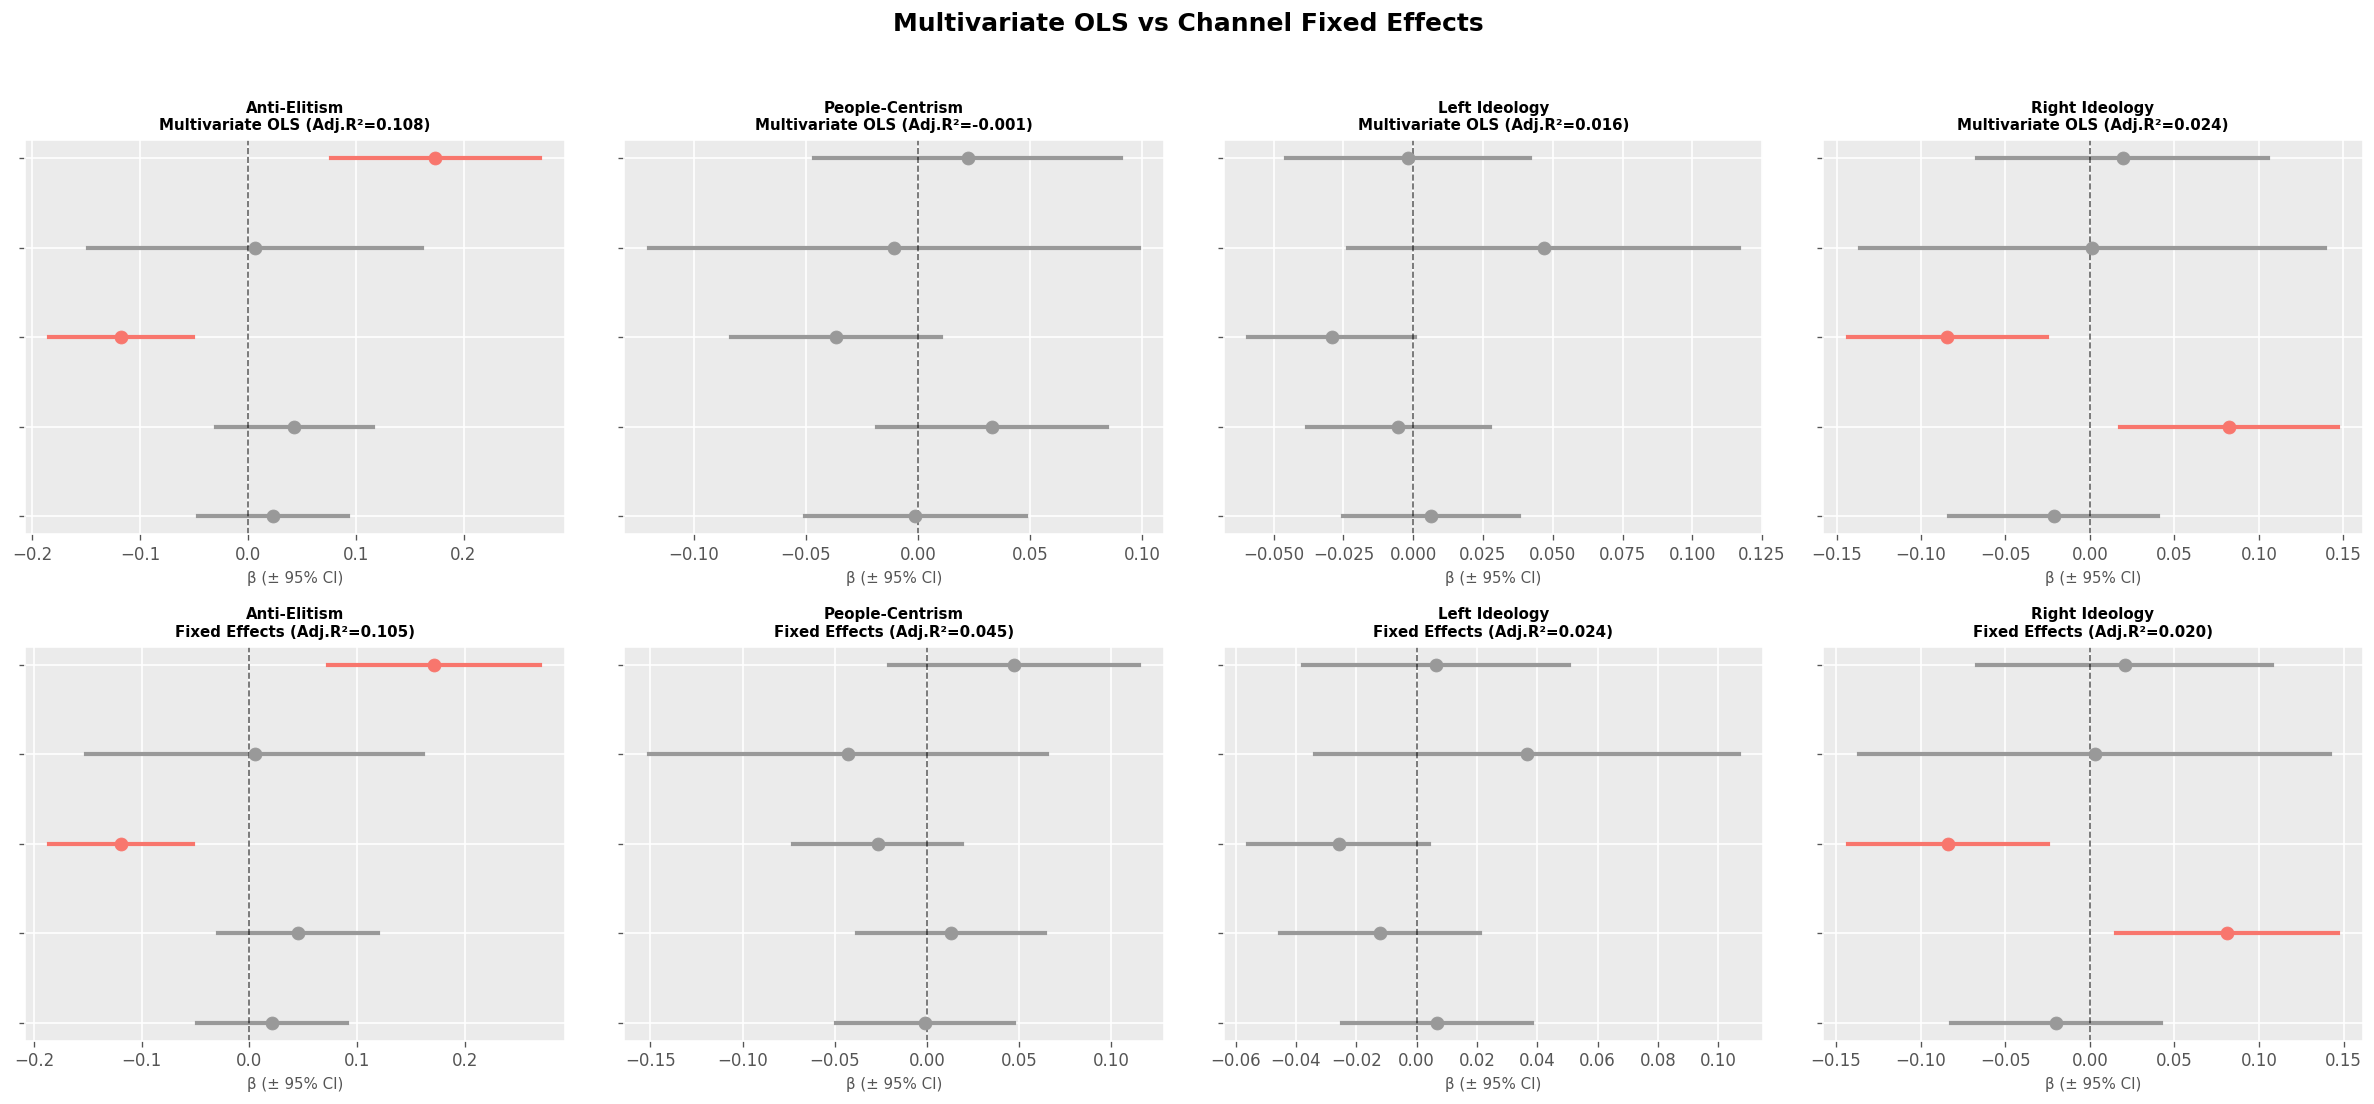

In [14]:
# ============================================================
# CHANNEL FIXED EFFECTS
# ============================================================

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

results_fe = {}

print("CHANNEL FIXED EFFECTS")
print("="*60)
print("(Within-channel variation only — between-channel differences absorbed)\n")

# Check how many videos per channel
channel_counts = df['channel_title'].value_counts()
print(f"  Channels: {df['channel_title'].nunique()}")
print(f"  Videos per channel — mean: {channel_counts.mean():.1f}, "
      f"min: {channel_counts.min()}, max: {channel_counts.max()}\n")

# Only keep channels with >1 video (fixed effects need within-group variation)
valid_channels = channel_counts[channel_counts > 1].index
df_fe = df[df['channel_title'].isin(valid_channels)].copy()
print(f"  Rows after dropping single-video channels: {len(df_fe)}\n")

pred_cols   = list(PREDICTORS.values())
pred_labels = list(PREDICTORS.keys())

for dim_label, dim_col in BERT_DIMS.items():
    subset = df_fe[[dim_col, 'channel_title'] + pred_cols].dropna()

    # Build formula with channel dummies (absorbed as fixed effects)
    pred_formula = ' + '.join(pred_cols)
    formula = f"{dim_col} ~ {pred_formula} + C(channel_title)"
    model = smf.ols(formula, data=subset).fit()

    results_fe[dim_label] = {
        'model':   model,
        'n':       len(subset),
        'r2':      model.rsquared,
        'r2_adj':  model.rsquared_adj,
    }

    print(f"  {dim_label}  (n={len(subset)}, R²={model.rsquared:.4f}, Adj.R²={model.rsquared_adj:.4f})")
    print(f"  {'Predictor':<22} {'β':>10} {'SE':>10} {'t':>8} {'p':>10} {'Sig':>5}")
    print(f"  {'-'*67}")
    for pred_label, pred_col in PREDICTORS.items():
        b  = model.params[pred_col]
        se = model.bse[pred_col]
        t  = model.tvalues[pred_col]
        p  = model.pvalues[pred_col]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {pred_label:<22} {b:>+10.4f} {se:>10.4f} {t:>8.3f} {p:>10.4f} {stars:>5}")
    print()


# ============================================================
# COMPARE: Multivariate vs Fixed Effects Adj. R²
# ============================================================

print("\nMODEL COMPARISON — Multivariate vs Fixed Effects Adj. R²")
print("="*60)
print(f"{'Dimension':<20} {'Multi Adj.R²':>14} {'FE Adj.R²':>12} {'ΔAdj.R²':>10}")
print("-"*60)
for dim_label in BERT_DIMS:
    multi_adj = results_multi[dim_label]['r2_adj']
    fe_adj    = results_fe[dim_label]['r2_adj']
    delta     = fe_adj - multi_adj
    print(f"{dim_label:<20} {multi_adj:>14.4f} {fe_adj:>12.4f} {delta:>+10.4f}")


# ============================================================
# COEFFICIENT PLOT — Multivariate vs Fixed Effects side by side
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey='row')
fig.suptitle('Multivariate OLS vs Channel Fixed Effects',
             fontsize=15, fontweight='bold', y=1.02)

for col, (dim_label, dim_col) in enumerate(BERT_DIMS.items()):
    for row, (res_dict, title) in enumerate([
        (results_multi, 'Multivariate OLS'),
        (results_fe,    'Fixed Effects')
    ]):
        ax = axes[row, col]
        model = res_dict[dim_label]['model']

        betas  = [model.params[c]             for c in pred_cols]
        cis_lo = [model.conf_int().loc[c, 0]  for c in pred_cols]
        cis_hi = [model.conf_int().loc[c, 1]  for c in pred_cols]
        pvals  = [model.pvalues[c]            for c in pred_cols]
        colors = [COLORS[0] if p < 0.05 else '#999999' for p in pvals]

        for i, (b, lo, hi, c) in enumerate(zip(betas, cis_lo, cis_hi, colors)):
            ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
            ax.scatter(b, i, color=c, s=60, zorder=5)

        ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
        ax.set_yticks(range(len(pred_labels)))
        ax.set_yticklabels(pred_labels if col == 0 else [])
        ax.set_xlabel('β (± 95% CI)', fontsize=9)
        adj = res_dict[dim_label]['r2_adj']
        ax.set_title(f'{dim_label}\n{title} (Adj.R²={adj:.3f})',
                     fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('popbert_fe_vs_multi.png', dpi=150, bbox_inches='tight')
plt.show()

ROBUST REGRESSION (Huber's T norm)
(Outliers downweighted — compare β to OLS to spot influential obs)

  Anti-Elitism  (n=400)
  Predictor                β (Robust)    β (OLS)         Δβ          p   Sig
  ------------------------------------------------------------------------
  Views (log)                 +0.0155    +0.0232    -0.0077     0.6758      
  Likes (log)                 +0.0543    +0.0430    +0.0113     0.1597      
  Comments (log)              -0.1237    -0.1176    -0.0061     0.0005   ***
  Duration (log)              +0.0066    +0.0063    +0.0003     0.9363      
  Word Count (log)            +0.1792    +0.1740    +0.0052     0.0005   ***

  People-Centrism  (n=400)
  Predictor                β (Robust)    β (OLS)         Δβ          p   Sig
  ------------------------------------------------------------------------
  Views (log)                 -0.0165    -0.0012    -0.0153     0.3264      
  Likes (log)                 +0.0430    +0.0331    +0.0099     0.0141     *
  

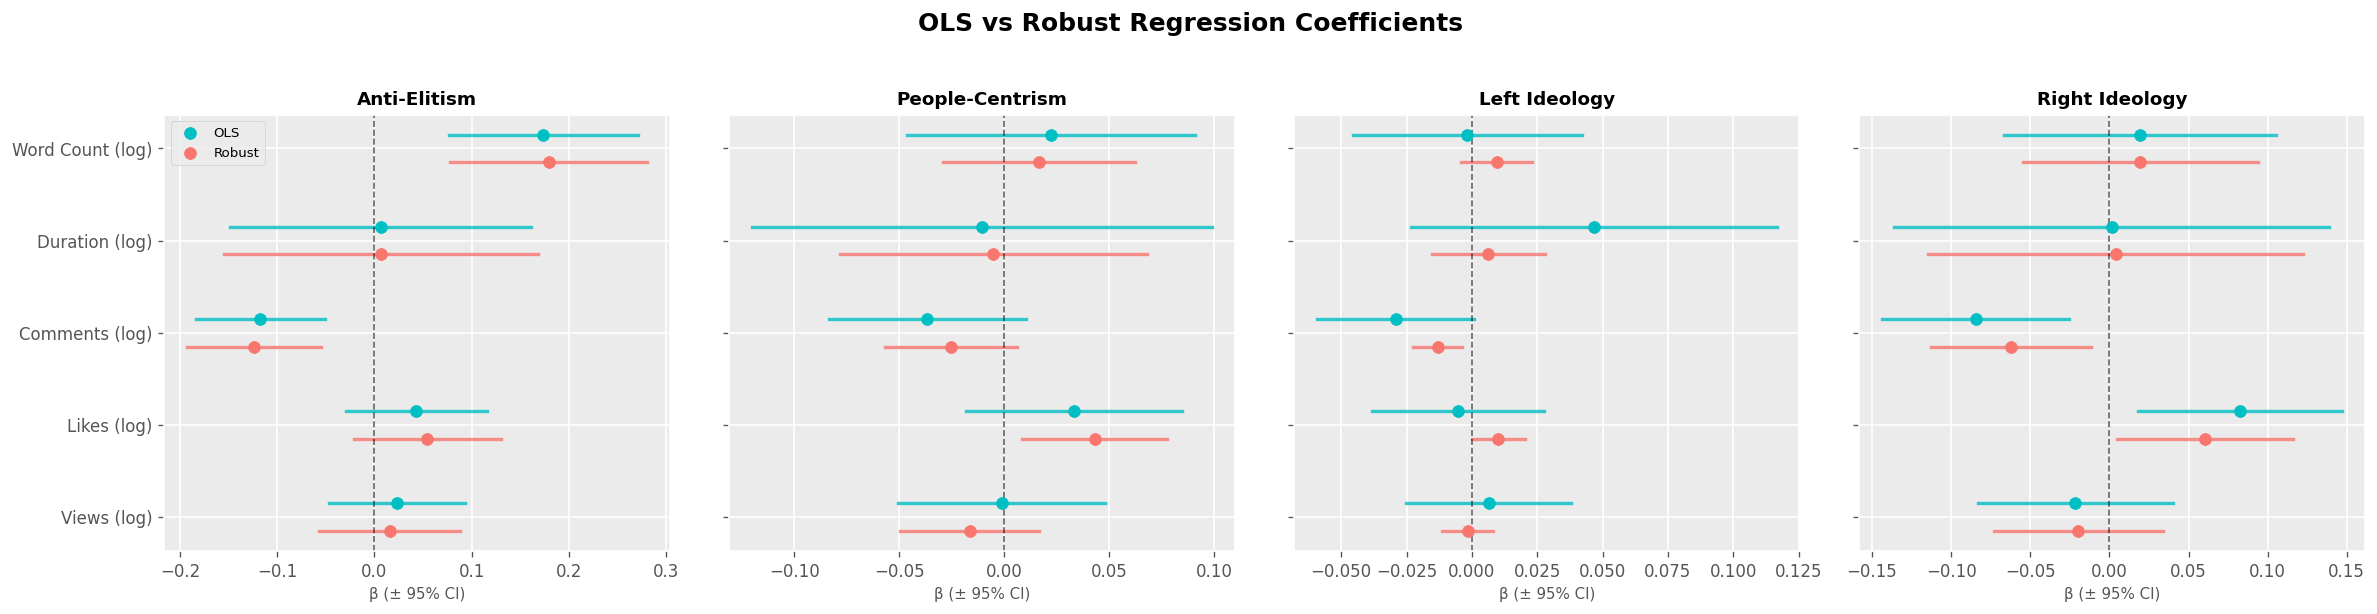

In [15]:
# ============================================================
# ROBUST REGRESSION — Downweights outliers automatically
# ============================================================

from statsmodels.robust.robust_linear_model import RLM
import statsmodels.robust.norms as norms

results_robust = {}

print("ROBUST REGRESSION (Huber's T norm)")
print("="*60)
print("(Outliers downweighted — compare β to OLS to spot influential obs)\n")

for dim_label, dim_col in BERT_DIMS.items():
    pred_cols = list(PREDICTORS.values())
    subset = df[[dim_col] + pred_cols].dropna()

    X = sm.add_constant(subset[pred_cols])
    y = subset[dim_col]

    # Huber's T — standard robust norm, good balance between efficiency and robustness
    model = RLM(y, X, M=norms.HuberT()).fit()

    results_robust[dim_label] = {
        'model': model,
        'n':     len(subset),
    }

    print(f"  {dim_label}  (n={len(subset)})")
    print(f"  {'Predictor':<22} {'β (Robust)':>12} {'β (OLS)':>10} {'Δβ':>10} {'p':>10} {'Sig':>5}")
    print(f"  {'-'*72}")
    for pred_label, pred_col in PREDICTORS.items():
        b_rob  = model.params[pred_col]
        b_ols  = results_multi[dim_label]['model'].params[pred_col]
        delta  = b_rob - b_ols
        p      = model.pvalues[pred_col]
        stars  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        flag   = ' ⚠️' if abs(delta) > 0.02 else ''
        print(f"  {pred_label:<22} {b_rob:>+12.4f} {b_ols:>+10.4f} {delta:>+10.4f} {p:>10.4f} {stars:>5}{flag}")
    print()


# ============================================================
# OUTLIER DETECTION — flag influential observations
# ============================================================

print("\nOUTLIER ANALYSIS — Most downweighted observations per dimension")
print("="*60)

outlier_flags = pd.DataFrame(index=df.index)

for dim_label, dim_col in BERT_DIMS.items():
    pred_cols = list(PREDICTORS.values())
    subset = df[[dim_col] + pred_cols].dropna()
    X = sm.add_constant(subset[pred_cols])
    y = subset[dim_col]

    model = RLM(y, X, M=norms.HuberT()).fit()
    weights = model.weights

    # Attach weights back to subset index
    weight_series = pd.Series(weights, index=subset.index, name=f'weight_{dim_label}')
    outlier_flags = outlier_flags.join(weight_series, how='outer')

    # Show 5 most downweighted
    low_weight = weight_series.nsmallest(5)
    print(f"\n  {dim_label} — lowest weights (most outlier-like):")
    for idx in low_weight.index:
        row = df.loc[idx]
        print(f"    w={low_weight[idx]:.3f} | {row['channel_title'][:30]:<30} "
              f"| views={int(row['view_count']):>10,} "
              f"| {dim_col}: {row[dim_col]:.3f}")


# ============================================================
# COMPARE: OLS vs Robust coefficients — visual
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('OLS vs Robust Regression Coefficients',
             fontsize=15, fontweight='bold', y=1.02)

pred_labels = list(PREDICTORS.keys())
pred_cols   = list(PREDICTORS.values())

for ax, (dim_label, dim_col) in zip(axes, BERT_DIMS.items()):
    ols_betas    = [results_multi[dim_label]['model'].params[c]  for c in pred_cols]
    robust_betas = [results_robust[dim_label]['model'].params[c] for c in pred_cols]
    ols_ci_lo    = [results_multi[dim_label]['model'].conf_int().loc[c, 0] for c in pred_cols]
    ols_ci_hi    = [results_multi[dim_label]['model'].conf_int().loc[c, 1] for c in pred_cols]
    robust_ci_lo = [results_robust[dim_label]['model'].conf_int().loc[c, 0] for c in pred_cols]
    robust_ci_hi = [results_robust[dim_label]['model'].conf_int().loc[c, 1] for c in pred_cols]

    y_pos = np.arange(len(pred_labels))

    # OLS — slightly offset up
    for i, (b, lo, hi) in enumerate(zip(ols_betas, ols_ci_lo, ols_ci_hi)):
        ax.plot([lo, hi], [i + 0.15, i + 0.15], color=COLORS[1], linewidth=2, alpha=0.8)
        ax.scatter(b, i + 0.15, color=COLORS[1], s=50, zorder=5, label='OLS' if i == 0 else '')

    # Robust — slightly offset down
    for i, (b, lo, hi) in enumerate(zip(robust_betas, robust_ci_lo, robust_ci_hi)):
        ax.plot([lo, hi], [i - 0.15, i - 0.15], color=COLORS[0], linewidth=2, alpha=0.8)
        ax.scatter(b, i - 0.15, color=COLORS[0], s=50, zorder=5, label='Robust' if i == 0 else '')

    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(pred_labels if ax == axes[0] else [])
    ax.set_xlabel('β (± 95% CI)', fontsize=9)
    ax.set_title(dim_label, fontsize=11, fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('popbert_robust_vs_ols.png', dpi=150, bbox_inches='tight')
plt.show()

BETA REGRESSION (Logit link, Binomial family approximation)
(Correct specification for proportional/probability outcomes)


  Anti-Elitism  (n=400)
  Predictor                β (Beta)    β (OLS)          p   Sig
  ------------------------------------------------------------
  Views (log)               +0.1171    +0.0232     0.5516      
  Likes (log)               +0.1793    +0.0430     0.3997      
  Comments (log)            -0.5350    -0.1176     0.0040    **
  Duration (log)            -0.0070    +0.0063     0.9877      
  Word Count (log)          +0.8193    +0.1740     0.0065    **

  People-Centrism  (n=400)
  Predictor                β (Beta)    β (OLS)          p   Sig
  ------------------------------------------------------------
  Views (log)               -0.0847    -0.0012     0.7639      
  Likes (log)               +0.3563    +0.0331     0.3399      
  Comments (log)            -0.2692    -0.0366     0.2436      
  Duration (log)            -0.1060    -0.0106     0.8433 

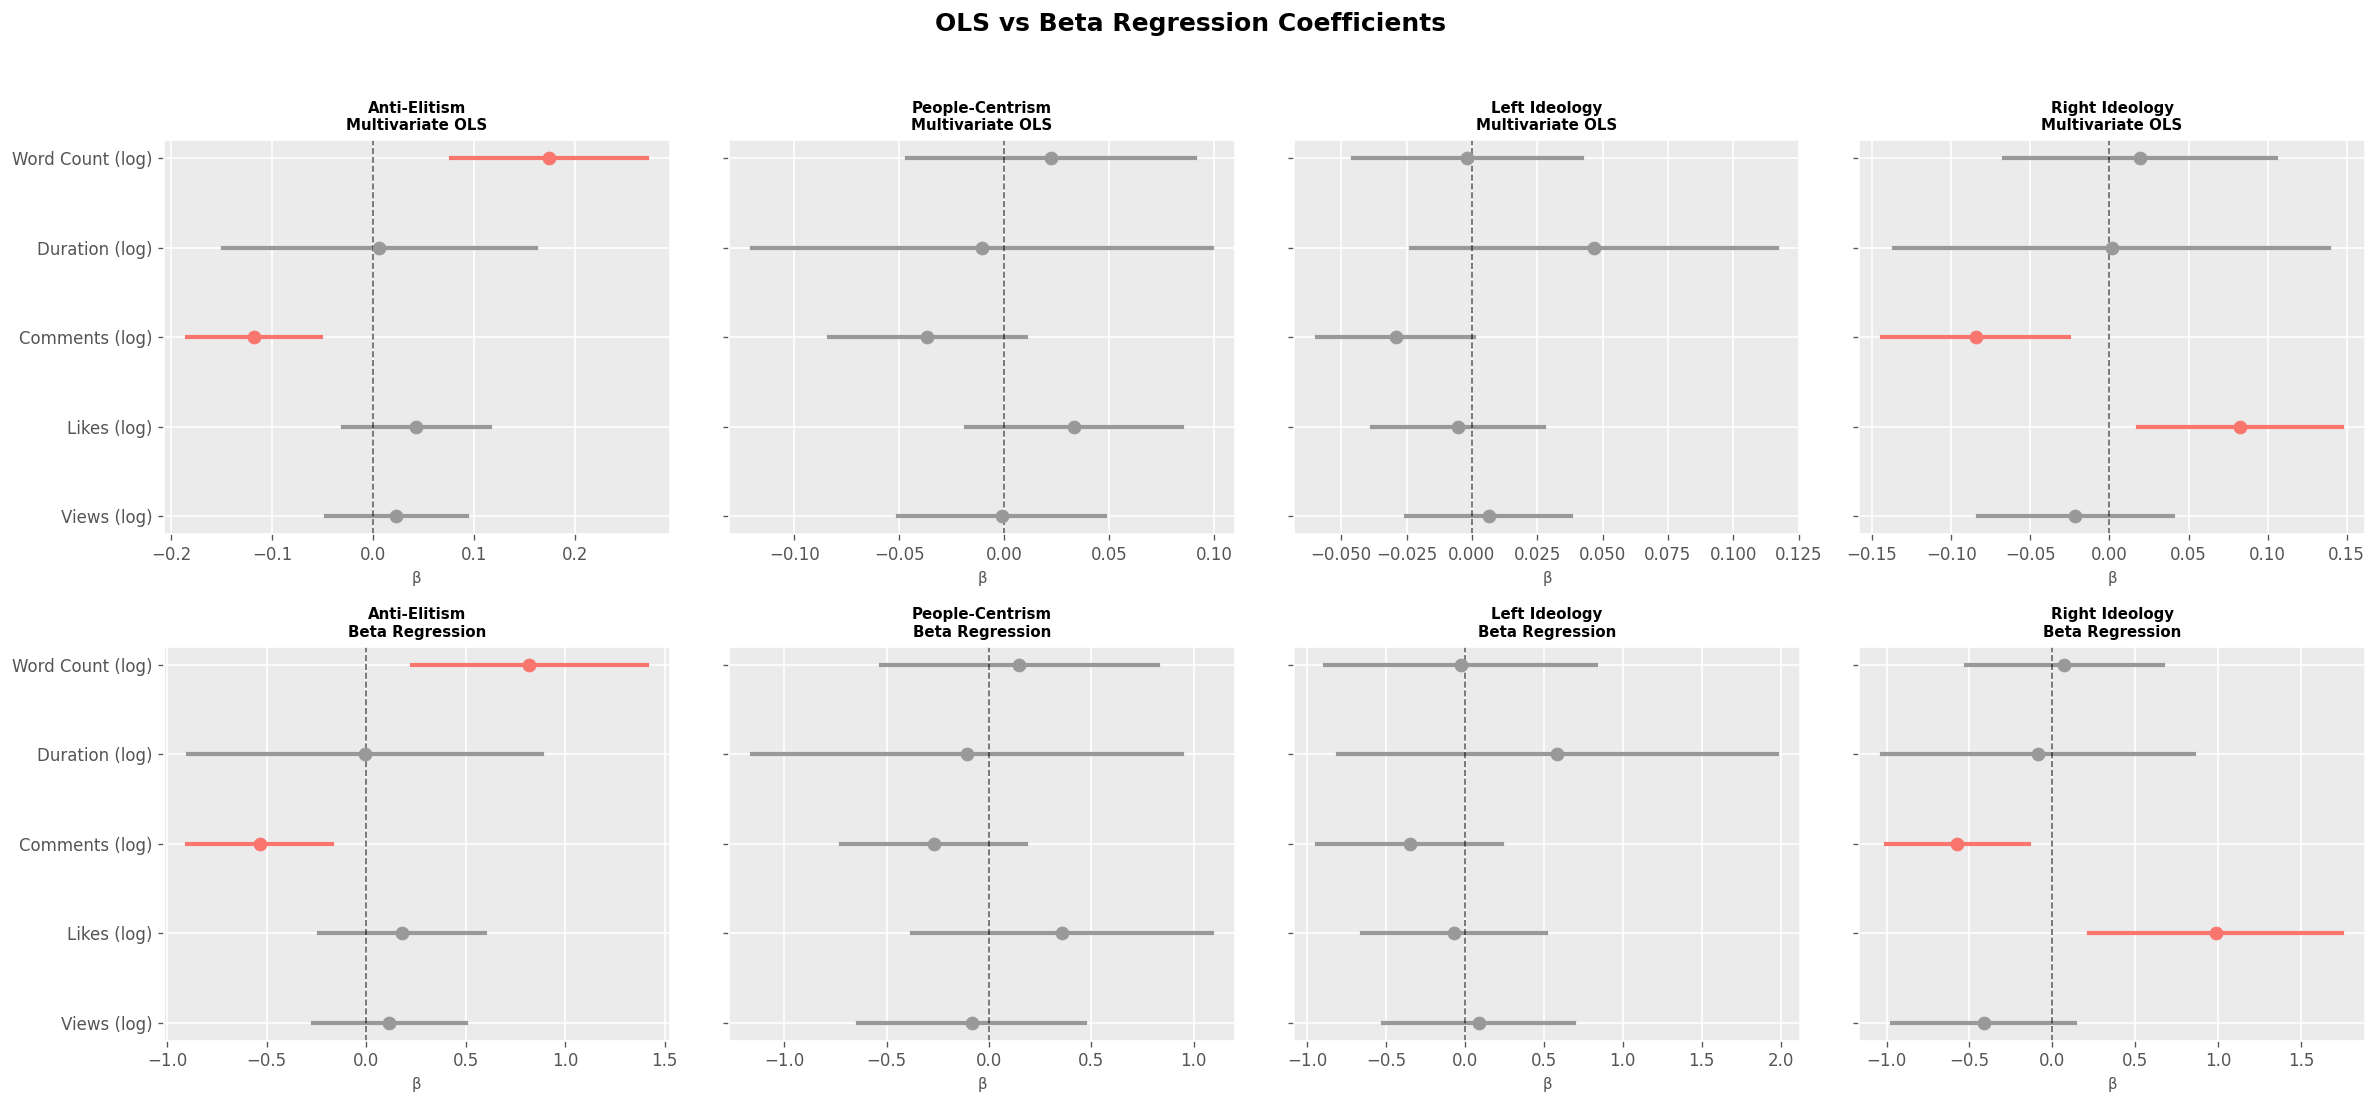

In [16]:
# ============================================================
# BETA REGRESSION — Correct model for bounded (0,1) outcomes
# ============================================================

# pip install betareg --break-system-packages
# Beta regression is not in statsmodels, we use the betareg package
# or implement via statsmodels GLM with a custom link

from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
import warnings
warnings.filterwarnings('ignore')

# Beta regression requires values strictly between 0 and 1
# Scores of exactly 0 or 1 need to be compressed slightly
def compress_01(series, epsilon=1e-6):
    """Compress [0,1] to (0,1) for beta regression."""
    return series.clip(epsilon, 1 - epsilon)

results_beta = {}

print("BETA REGRESSION (Logit link, Binomial family approximation)")
print("="*60)
print("(Correct specification for proportional/probability outcomes)\n")

for dim_label, dim_col in BERT_DIMS.items():
    pred_cols = list(PREDICTORS.values())
    subset = df[[dim_col] + pred_cols].dropna().copy()

    # Compress outcome to open interval
    n_zeros = (subset[dim_col] == 0).sum()
    n_ones  = (subset[dim_col] == 1).sum()
    if n_zeros > 0 or n_ones > 0:
        print(f"  [{dim_label}] Compressing {n_zeros} zeros and {n_ones} ones")
    subset[dim_col] = compress_01(subset[dim_col])

    X = sm.add_constant(subset[pred_cols])
    y = subset[dim_col]

    # GLM with Binomial family + logit link
    # This approximates beta regression and is available natively in statsmodels
    model = GLM(y, X, family=families.Binomial(link=families.links.Logit())).fit()

    results_beta[dim_label] = {
        'model':  model,
        'n':      len(subset),
    }

    print(f"\n  {dim_label}  (n={len(subset)})")
    print(f"  {'Predictor':<22} {'β (Beta)':>10} {'β (OLS)':>10} {'p':>10} {'Sig':>5}")
    print(f"  {'-'*60}")
    for pred_label, pred_col in PREDICTORS.items():
        b_beta = model.params[pred_col]
        b_ols  = results_multi[dim_label]['model'].params[pred_col]
        p      = model.pvalues[pred_col]
        stars  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {pred_label:<22} {b_beta:>+10.4f} {b_ols:>+10.4f} {p:>10.4f} {stars:>5}")


# ============================================================
# MARGINAL EFFECTS — convert log-odds to probability scale
# ============================================================

print("\n\nMARGINAL EFFECTS (at mean) — probability scale")
print("="*60)
print("(How much does a 1-unit increase in predictor change P(populism)?)\n")

for dim_label, dim_col in BERT_DIMS.items():
    pred_cols = list(PREDICTORS.values())
    subset = df[[dim_col] + pred_cols].dropna().copy()
    subset[dim_col] = compress_01(subset[dim_col])

    X = sm.add_constant(subset[pred_cols])
    y = subset[dim_col]
    model = results_beta[dim_label]['model']

    # Marginal effect at mean: dP/dx = β * P̄ * (1 - P̄)
    p_mean = float(y.mean())
    scale  = p_mean * (1 - p_mean)

    print(f"  {dim_label}  (mean score = {p_mean:.3f})")
    print(f"  {'Predictor':<22} {'log-odds β':>12} {'Marginal ΔP':>14} {'p':>10} {'Sig':>5}")
    print(f"  {'-'*65}")
    for pred_label, pred_col in PREDICTORS.items():
        b   = model.params[pred_col]
        me  = b * scale
        p   = model.pvalues[pred_col]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {pred_label:<22} {b:>+12.4f} {me:>+14.4f} {p:>10.4f} {stars:>5}")
    print()


# ============================================================
# COMPARE: OLS vs Beta — coefficient plot
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('OLS vs Beta Regression Coefficients',
             fontsize=15, fontweight='bold', y=1.02)

pred_labels = list(PREDICTORS.keys())
pred_cols   = list(PREDICTORS.values())

for col, (dim_label, dim_col) in enumerate(BERT_DIMS.items()):
    for row, (res_dict, title) in enumerate([
        (results_multi, 'Multivariate OLS'),
        (results_beta,  'Beta Regression'),
    ]):
        ax = axes[row, col]
        model  = res_dict[dim_label]['model']
        betas  = [model.params[c]            for c in pred_cols]
        cis_lo = [model.conf_int().loc[c, 0] for c in pred_cols]
        cis_hi = [model.conf_int().loc[c, 1] for c in pred_cols]
        pvals  = [model.pvalues[c]           for c in pred_cols]
        colors = [COLORS[0] if p < 0.05 else '#999999' for p in pvals]

        for i, (b, lo, hi, c) in enumerate(zip(betas, cis_lo, cis_hi, colors)):
            ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
            ax.scatter(b, i, color=c, s=60, zorder=5)

        ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
        ax.set_yticks(range(len(pred_labels)))
        ax.set_yticklabels(pred_labels if col == 0 else [])
        ax.set_xlabel('β', fontsize=9)
        ax.set_title(f'{dim_label}\n{title}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('popbert_beta_vs_ols.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ============================================================
# INTERACTION MODELS
# ============================================================

results_interact = {}

# Fix: deduplicate df columns first
df = df.loc[:, ~df.columns.duplicated()].copy()
df = df.reset_index(drop=True)

# Create ideology lean
df['ideology_lean'] = np.where(
    df['bert_left_ideology'] > df['bert_right_ideology'], 'Left', 'Right'
)

print(f"Ideology split: {df['ideology_lean'].value_counts().to_dict()}\n")

ROBUST_PREDICTORS = {
    'Word Count (log)': 'log_word_count',
    'Comments (log)':   'log_comment_count',
    'Likes (log)':      'log_like_count',
}

print("INTERACTION MODELS: Predictor × Ideology Lean")
print("="*60)

for dim_label, dim_col in BERT_DIMS.items():
    results_interact[dim_label] = {}
    print(f"\n{'='*60}")
    print(f"  {dim_label}")
    print(f"{'='*60}")

    for pred_label, pred_col in ROBUST_PREDICTORS.items():
        subset = df[[dim_col, pred_col, 'ideology_lean'] +
                    list(PREDICTORS.values())].dropna().reset_index(drop=True).copy()

        subset['right_dummy'] = (subset['ideology_lean'] == 'Right').astype(int)
        
        # KEY FIX: use .values to avoid any index alignment issues entirely
        subset['interaction'] = subset[pred_col].values * subset['right_dummy'].values

        ctrl_cols = [c for c in PREDICTORS.values() if c != pred_col]
        X = sm.add_constant(
            subset[[pred_col, 'right_dummy', 'interaction'] + ctrl_cols]
        )
        y = subset[dim_col]
        model = sm.OLS(y, X).fit()

        results_interact[dim_label][pred_label] = {
            'model':      model,
            'b_pred':     model.params[pred_col],
            'b_right':    model.params['right_dummy'],
            'b_interact': model.params['interaction'],
            'p_pred':     model.pvalues[pred_col],
            'p_right':    model.pvalues['right_dummy'],
            'p_interact': model.pvalues['interaction'],
            'r2_adj':     model.rsquared_adj,
            'n':          len(subset),
        }

        p_int   = model.pvalues['interaction']
        stars   = '***' if p_int < 0.001 else '**' if p_int < 0.01 else '*' if p_int < 0.05 else 'n.s.'
        slope_left  = model.params[pred_col]
        slope_right = model.params[pred_col] + model.params['interaction']

        print(f"\n  ~ {pred_label}")
        print(f"    Slope (Left content):  β = {slope_left:+.4f}")
        print(f"    Slope (Right content): β = {slope_right:+.4f}")
        print(f"    Interaction β:         {model.params['interaction']:+.4f}  "
              f"(p = {p_int:.4f}) {stars}")
        print(f"    Adj. R²: {model.rsquared_adj:.4f}")


# ============================================================
# SIMPLE SLOPES PLOT
# ============================================================

fig, axes = plt.subplots(
    len(BERT_DIMS), len(ROBUST_PREDICTORS),
    figsize=(18, 16)
)
fig.suptitle('Interaction Models: Predictor × Ideology Lean\n(Left vs Right content)',
             fontsize=15, fontweight='bold', y=1.01)

for row, (dim_label, dim_col) in enumerate(BERT_DIMS.items()):
    for col, (pred_label, pred_col) in enumerate(ROBUST_PREDICTORS.items()):
        ax = axes[row, col]

        subset = df[[dim_col, pred_col, 'ideology_lean']].dropna().reset_index(drop=True)

        for group, color in [('Left', COLORS[1]), ('Right', COLORS[0])]:
            grp = subset[subset['ideology_lean'] == group].reset_index(drop=True)
            x = grp[pred_col].values  # use .values throughout plotting too
            y = grp[dim_col].values

            ax.scatter(x, y, alpha=0.25, s=12, color=color, linewidths=0)

            X_grp = sm.add_constant(x)
            m = sm.OLS(y, X_grp).fit()
            x_range = np.linspace(x.min(), x.max(), 200)
            pred = m.get_prediction(
                sm.add_constant(pd.DataFrame({pred_col: x_range}))
            ).summary_frame(alpha=0.05)

            ax.plot(x_range, pred['mean'], color=color, linewidth=2, label=group)
            ax.fill_between(x_range, pred['mean_ci_lower'], pred['mean_ci_upper'],
                            alpha=0.2, color=color)

        r     = results_interact[dim_label][pred_label]
        p     = r['p_interact']
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        ax.annotate(
            f'Interaction: {stars}\np = {p:.3f}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            va='top', ha='left', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

        if row == 0:
            ax.set_title(pred_label, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(dim_label, fontsize=9, fontweight='bold')
        if row == len(BERT_DIMS) - 1:
            ax.set_xlabel(pred_label, fontsize=8)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, title='Ideology')

plt.tight_layout()
plt.savefig('popbert_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

Ideology split: {'Right': 269, 'Left': 141}

INTERACTION MODELS: Predictor × Ideology Lean

  Anti-Elitism


ValueError: operands could not be broadcast together with shapes (400,2) (400,) 

MULTILEVEL MODEL — Random Intercept per Channel
(Accounts for clustering: videos nested within channels)

INTRACLASS CORRELATION (ICC) per dimension
(ICC = proportion of total variance explained by channel membership)
------------------------------------------------------------
  Anti-Elitism         ICC = 0.000  (σ²_channel = 0.0000, σ²_residual = 0.1738)
  People-Centrism      ICC = 0.145  (σ²_channel = 0.0125, σ²_residual = 0.0736)
  Left Ideology        ICC = 0.024  (σ²_channel = 0.0008, σ²_residual = 0.0319)
  Right Ideology       ICC = 0.000  (σ²_channel = 0.0000, σ²_residual = 0.1250)


FULL MIXED MODEL — Fixed effects (controlling for random channel intercept)

  Anti-Elitism  (n=400, ICC=0.002)
  Predictor               β (Mixed)    β (OLS)          p   Sig
  ------------------------------------------------------------
  Views (log)               +0.0232    +0.0232     0.5128      
  Likes (log)               +0.0430    +0.0430     0.2459      
  Comments (log)            -0.1

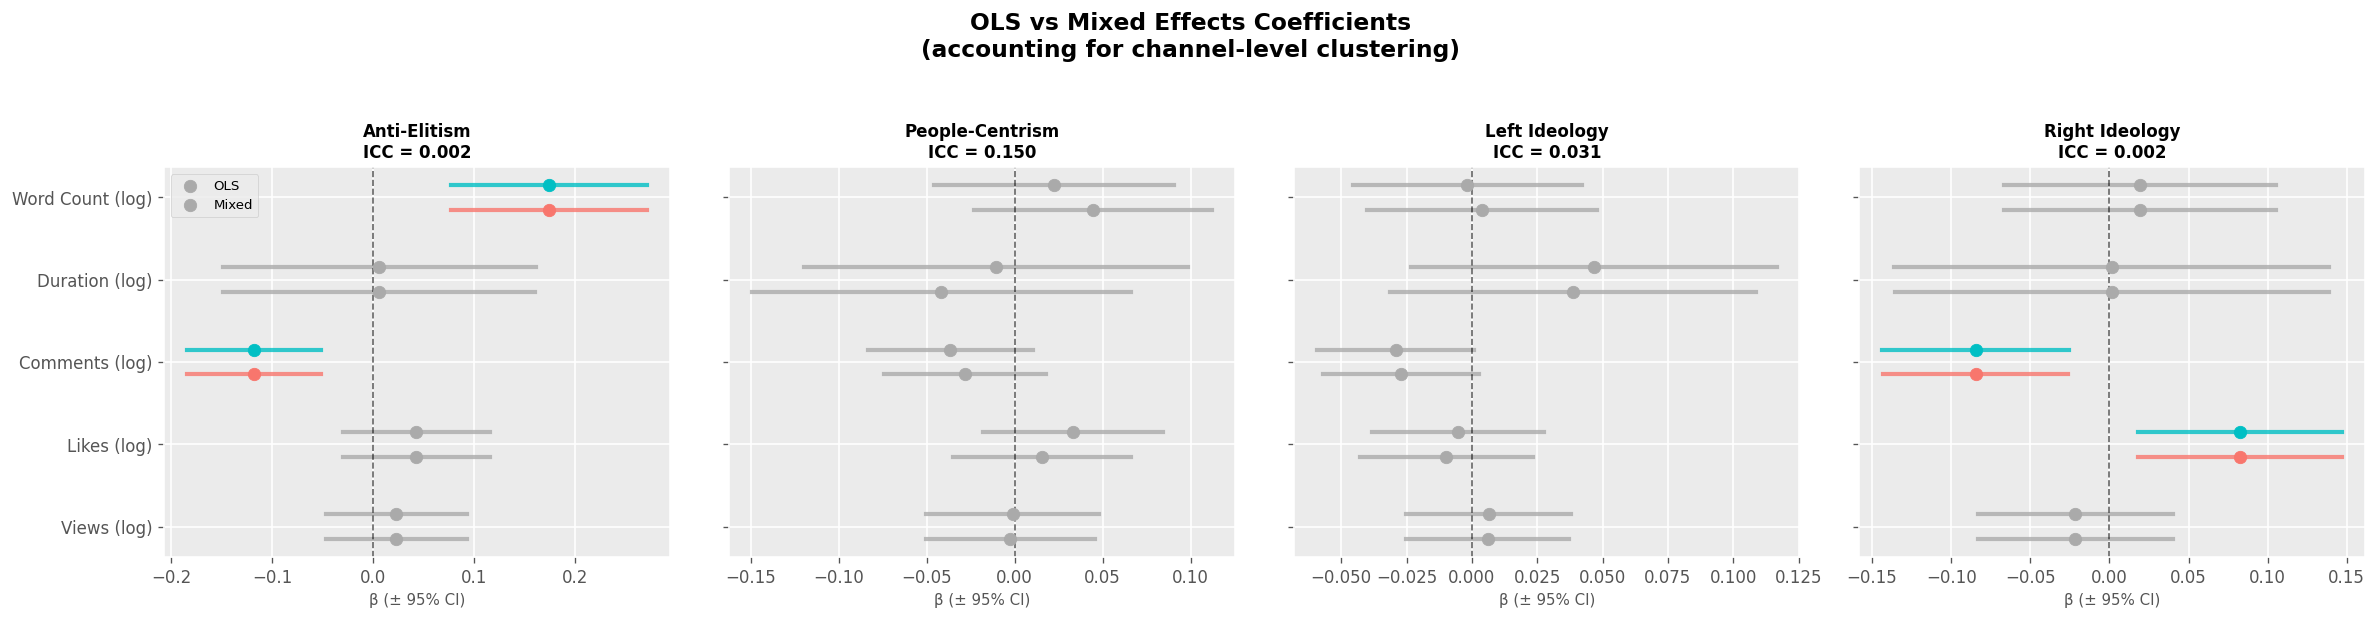

In [22]:
# ============================================================
# MULTILEVEL / MIXED EFFECTS MODEL
# ============================================================
# Random intercept per channel — proper treatment of clustered data
# Channels vary in baseline populism; we want within-channel effects
# ============================================================

# pip install pymer4 --break-system-packages
# pymer4 wraps R's lme4 — most reliable mixed effects in Python
# Alternative: statsmodels MixedLM (pure Python, no R needed)

from statsmodels.regression.mixed_linear_model import MixedLM

results_mixed = {}

print("MULTILEVEL MODEL — Random Intercept per Channel")
print("="*60)
print("(Accounts for clustering: videos nested within channels)\n")

# Check ICC first — how much variance is at channel level?
print("INTRACLASS CORRELATION (ICC) per dimension")
print("(ICC = proportion of total variance explained by channel membership)")
print("-"*60)

for dim_label, dim_col in BERT_DIMS.items():
    subset = df[[dim_col, 'channel_title']].dropna().reset_index(drop=True)

    # Null model (intercept only) to get ICC
    null_model = MixedLM(
        subset[dim_col],
        np.ones((len(subset), 1)),
        groups=subset['channel_title']
    ).fit(reml=True)

    var_channel  = float(null_model.cov_re.iloc[0, 0])
    var_residual = float(null_model.scale)
    icc = var_channel / (var_channel + var_residual)

    print(f"  {dim_label:<20} ICC = {icc:.3f}  "
          f"(σ²_channel = {var_channel:.4f}, σ²_residual = {var_residual:.4f})")

print()


# Full mixed model with all predictors
print("\nFULL MIXED MODEL — Fixed effects (controlling for random channel intercept)")
print("="*60)

pred_cols   = list(PREDICTORS.values())
pred_labels = list(PREDICTORS.keys())

for dim_label, dim_col in BERT_DIMS.items():
    subset = df[[dim_col, 'channel_title'] + pred_cols].dropna().reset_index(drop=True)

    # Design matrix for fixed effects
    X = sm.add_constant(subset[pred_cols])

    model = MixedLM(
        subset[dim_col],
        X,
        groups=subset['channel_title']
    ).fit(reml=True)

    results_mixed[dim_label] = {
        'model':      model,
        'n':          len(subset),
        'var_channel': float(model.cov_re.iloc[0, 0]),
        'var_resid':   float(model.scale),
    }

    icc = results_mixed[dim_label]['var_channel'] / (
        results_mixed[dim_label]['var_channel'] +
        results_mixed[dim_label]['var_resid']
    )

    print(f"\n  {dim_label}  (n={len(subset)}, ICC={icc:.3f})")
    print(f"  {'Predictor':<22} {'β (Mixed)':>10} {'β (OLS)':>10} {'p':>10} {'Sig':>5}")
    print(f"  {'-'*60}")
    for pred_label, pred_col in PREDICTORS.items():
        b_mix = model.fe_params[pred_col]
        b_ols = results_multi[dim_label]['model'].params[pred_col]
        p     = model.pvalues[pred_col]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {pred_label:<22} {b_mix:>+10.4f} {b_ols:>+10.4f} {p:>10.4f} {stars:>5}")

    print(f"\n  Random effects variance (channel): {results_mixed[dim_label]['var_channel']:.4f}")
    print(f"  Residual variance:                 {results_mixed[dim_label]['var_resid']:.4f}")


# ============================================================
# COMPARE: OLS vs Mixed coefficients — forest plot
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('OLS vs Mixed Effects Coefficients\n(accounting for channel-level clustering)',
             fontsize=14, fontweight='bold', y=1.03)

for ax, (dim_label, dim_col) in zip(axes, BERT_DIMS.items()):
    model_ols = results_multi[dim_label]['model']
    model_mix = results_mixed[dim_label]['model']

    y_pos = np.arange(len(pred_labels))

    for i, pred_col in enumerate(pred_cols):
        # OLS — offset up
        b_ols  = model_ols.params[pred_col]
        lo_ols = model_ols.conf_int().loc[pred_col, 0]
        hi_ols = model_ols.conf_int().loc[pred_col, 1]
        p_ols  = model_ols.pvalues[pred_col]
        c_ols  = COLORS[1] if p_ols < 0.05 else '#aaaaaa'

        ax.plot([lo_ols, hi_ols], [i + 0.15, i + 0.15], color=c_ols, linewidth=2.5, alpha=0.8)
        ax.scatter(b_ols, i + 0.15, color=c_ols, s=55, zorder=5,
                   label='OLS' if i == 0 else '')

        # Mixed — offset down
        b_mix  = model_mix.fe_params[pred_col]
        lo_mix = model_mix.conf_int().loc[pred_col, 0]
        hi_mix = model_mix.conf_int().loc[pred_col, 1]
        p_mix  = model_mix.pvalues[pred_col]
        c_mix  = COLORS[0] if p_mix < 0.05 else '#aaaaaa'

        ax.plot([lo_mix, hi_mix], [i - 0.15, i - 0.15], color=c_mix, linewidth=2.5, alpha=0.8)
        ax.scatter(b_mix, i - 0.15, color=c_mix, s=55, zorder=5,
                   label='Mixed' if i == 0 else '')

    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(pred_labels if ax == axes[0] else [])
    ax.set_xlabel('β (± 95% CI)', fontsize=9)

    icc = results_mixed[dim_label]['var_channel'] / (
        results_mixed[dim_label]['var_channel'] +
        results_mixed[dim_label]['var_resid']
    )
    ax.set_title(f'{dim_label}\nICC = {icc:.3f}', fontsize=10, fontweight='bold')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('popbert_mixed_vs_ols.png', dpi=150, bbox_inches='tight')
plt.show()